<h1 align="center">NSDC Data Science Projects</h1>

<h1 align="center">Project : Customer Segmentation Analysis</h1>

<h3 align="center">Trupti Shailendra Gandhi </h3>
<h3 align="center">Girish Sunkadakatte Chandrappa</h3>

## Problem Statement:

-> The current marketing strategy lacks a clear understanding of customer behavior and response patterns across different campaigns. Without effectively utilizing available data such as demographics, purchase history, and previous campaign acceptance the company struggles to optimize targeting and improve campaign outcomes.

-> This project aims to build a model to predict customer response to marketing campaigns, identify key influencing factors, and help the company enhance customer targeting, boost campaign performance, and reduce marketing costs.

## Objective:

To build a model to predict whether the customer will respond to an offer for a product or service.

## Data Description:

1. ID: unique identification code for customer

2. Year_Birth: Customer's birth year

3. AcceptedCmp1 - Whether the customer accepted the offer from Campaign 1. (1=Accepted, 0=Not Accepted)

4. AcceptedCmp2 - Whether the customer accepted the offer from Campaign 2. (1=Accepted, 0=Not Accepted)

5. AcceptedCmp3 - Whether the customer accepted the offer from Campaign 3. (1=Accepted, 0=Not Accepted)

6. AcceptedCmp4 - Whether the customer accepted the offer from Campaign 4. (1=Accepted, 0=Not Accepted)

7. AcceptedCmp5 - Whether the customer accepted the offer from Campaign 5. (1=Accepted, 0=Not Accepted)

8. Complain - Whether the customer has complained in the last 2 years (1=Yes,0=No)

9. MntFishProducts - Amount spent on fish products in the last 2 years

10. MntMeatProducts - Amount spent on meat products in the last 2 years

11. MntFruits - Amount spent on fruits products in the last 2 years

12. MntSweetProducts - Amount spent on sweet products in the last 2 years

13. MntWines - Amount spent on wine products in the last 2 years

14. MntGoldProds - Amount spent on gold products in the last 2 years

15. NumDealsPurchases - Number of purchases made with discount

16. NumCatalogPurchases - Number of purchases made using catalogue

17. NumStorePurchases - Number of purchases made directly in stores

18. NumWebPurchases - Number of purchases made through company’s web site

19. NumWebVisitsMonth - Number of visits to company’s web site in the last month

20. DtCustomer - Customer's enrollment date in the company

21. Education - The level of education customer has completed

22. Marital - Status of customer's marraige

23. Kidhome - Number of children under age 13 at customer's home

24. Teenhome - Number of children between age 13-19 at customer's home

25. Income - Annual income of customer

26. Recency - Number of days since the last purchase

27. Z_CostContact - Customer's hidden cost per contact

28. Z_Revenue - Customer's hidden revenue

29. Response - (Target variable) Whether the customer accepted the offer from Campaign 1. (1=Accepted, 0=Not Accepted)
 

In [627]:
#Importing required libraries

import pandas as pd
import numpy as np
import seaborn as sns
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split,  GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE, SMOTENC
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from datetime import datetime
import matplotlib.pyplot as plt


In [628]:
# importing the dataset
customer_data = pd.read_excel("E:\\UTA materials\\Sem 2\\NSDC\\marketing_campaign.xlsx")

In [629]:
# copying data to another varaible to avoid any changes to original data
data=customer_data.copy()

In [ ]:
# display the first 5 rows of the data
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
# display the last 5 rows of the data
data.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,2012-10-15,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1


In [632]:
# checking the size of the dataset
print(f'The dataset contains {data.shape[0]} observations and {data.shape[1]} features')

The dataset contains 2240 observations and 29 features


In [633]:
# check the data types of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

#### The dataset contains:
- 3 categorical features.
- 26 numerical features with 1 feature as float64 datatype and 25 features as int64 datatype.

In [ ]:
#modifying the column names by replacing spaces with under score and converting them to lower case .
def clean_column_names(df):
    df.columns = [c.lower() for c in df.columns]
    df.columns = [c.replace(' ','_') for c in df.columns] 
    return df

In [635]:
clean_column_names(data)

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,z_costcontact,z_revenue,response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


In [ ]:
#Checking for missing values in the data set
data.isnull().sum()

id                      0
year_birth              0
education               0
marital_status          0
income                 24
kidhome                 0
teenhome                0
dt_customer             0
recency                 0
mntwines                0
mntfruits               0
mntmeatproducts         0
mntfishproducts         0
mntsweetproducts        0
mntgoldprods            0
numdealspurchases       0
numwebpurchases         0
numcatalogpurchases     0
numstorepurchases       0
numwebvisitsmonth       0
acceptedcmp3            0
acceptedcmp4            0
acceptedcmp5            0
acceptedcmp1            0
acceptedcmp2            0
complain                0
z_costcontact           0
z_revenue               0
response                0
dtype: int64

- Income feature has 24 missing values, we will address it later.

In [638]:
# Summary of the dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
year_birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
mntwines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
mntfruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
mntmeatproducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
mntfishproducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


**Observations:**
- z__cost_contact and z__revenue features have constant values so it won't contribute useful information to modeling, so we will drop them.
- Only 0.9% customers have lodged a complained in last 2 years.
- There is a large difference between the 3rd quartile and maximum value for features like id, income, mnt_wines, mnt_fruits, mnt_meat_products, mnt_fish_products, mnt_sweet_products, mnt_gold_prods,num_web_purchases, num_catalog_purchases, num_web_visits_month  which suggest that there might be outliers present in the data.
- Wine is the most purchased category in last 2 years with an average spent of $303.
- The accepted offer rate for the previous campaigns are around 7%, while 14.9% customers responded for the latest campaign, which indicates the imbalance in the target variable.

In [ ]:
#Checking unique value count in the feature z_costcontact and z_revenue
data[['z_costcontact','z_revenue']].value_counts()

z_costcontact  z_revenue
3              11           2240
Name: count, dtype: int64

In [ ]:
#Dropping z_costcontact and z_revenue since they contain constant values
data.drop(['z_costcontact', 'z_revenue','id'], axis=1, inplace=True)

- z__cost_contact, z__revenue features are having constant values so it won't be useful for modeling, so we are dropping them. Also feature 'id' is an unique identifier hence we are dropping that as well.

## Exploratory data Analysis

### Feature engineering for EDA

In [ ]:
#Taking copy of the data set only to perform Analysis on the data and understand the trends between the features.
data_eda = data.copy()

In [643]:
#Converting the year of birth column to age by taking today's year as consideration
current_year = datetime.now().year
print(f'current year is : {current_year}')

data_eda['age'] = current_year - data_eda['year_birth']

data.head()


current year is : 2025


,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


In [ ]:
#performing feature engineering on feature marital_status and grouping them into three categories

data_eda.loc[(data_eda['marital_status'] == 'Single') | 
         (data_eda['marital_status'] == 'Divorced') | 
         (data_eda['marital_status'] == 'Widow') | 
         (data_eda['marital_status'] == 'Alone'), 'marital_status'] = 'Living alone'

data_eda.loc[(data_eda['marital_status'] == 'Together') | 
         (data_eda['marital_status'] == 'Married'), 'marital_status'] = 'Not Living alone'

data_eda.loc[(data_eda['marital_status'] == 'Absurd') | 
         (data_eda['marital_status'] == 'YOLO'), 'marital_status'] = 'Other'

In [645]:
#combining feature kidhome and teenhome
data_eda['totalkids'] = data_eda['kidhome'] + data_eda['teenhome']

In [ ]:
# Converting the feature df_customer to datetime format
data_eda['dt_customer'] = pd.to_datetime(data_eda['dt_customer'])

# Calculating the number of yeards enrolled to the company for each customer
today = pd.to_datetime("today")
data_eda['years_enrolled'] = ((today - data_eda['dt_customer']).dt.days / 365).astype(int)

In [647]:
#converting column age into different categories.
#Age	    Category
#<25	    Youth
#25-34	    Young Adult
#35-49	    Adult
#50-64	    Senior
#>=65	    Elderly

data_eda['age'] = data_eda['age'].astype(float)

data_eda.loc[data_eda['age'] < 25, 'age_group'] = 'youth'
data_eda.loc[(data_eda['age'] >= 25) & (data_eda['age'] <= 34), 'age_group'] = 'young adult'
data_eda.loc[(data_eda['age'] >= 35) & (data_eda['age'] <= 49), 'age_group'] = 'adult'
data_eda.loc[(data_eda['age'] >= 50) & (data_eda['age'] <= 64), 'age_group'] = 'senior'
data_eda.loc[data_eda['age'] >= 65, 'age_group'] = 'Elderly'

data_eda['age_group'].value_counts().sum

<bound method Series.sum of age_group
senior         926
adult          652
Elderly        619
young adult     43
Name: count, dtype: int64>

In [ ]:
#Grouping recency feature into 5 distinct categories and assigning the values with new feature name 'recency_group'
bins = [0, 15, 45, 75, 100, 150]
labels = ['Active Loyalists', 'Warm Leads', 'Fading Customers', 'At-Risk Segment', 'Lapsed Customers']

# Creating recency groups
data_eda['recency_group'] = pd.cut(data_eda['recency'], bins=bins, labels=labels, right=True)

In [ ]:
# Grouping income feature into 3 distinct categories and assigning the values with new feature name 'income_group'
income_bins = [0, 40000, 80000, data['income'].max()]
income_labels = ['Low', 'Medium', 'High']

# Apply grouping
data_eda['income_group'] = pd.cut(data_eda['income'], bins=income_bins, labels=income_labels, right=True)

In [650]:
data_eda.head()

,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,totalkids,years_enrolled,age_group,recency_group,income_group
0,1957,Graduation,Living alone,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,68.0,0,12,Elderly,Fading Customers,Medium
1,1954,Graduation,Living alone,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,71.0,2,11,Elderly,Warm Leads,Medium
2,1965,Graduation,Not Living alone,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,60.0,0,11,senior,Warm Leads,Medium
3,1984,Graduation,Not Living alone,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,41.0,1,11,adult,Warm Leads,Low
4,1981,PhD,Not Living alone,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,44.0,1,11,adult,At-Risk Segment,Medium


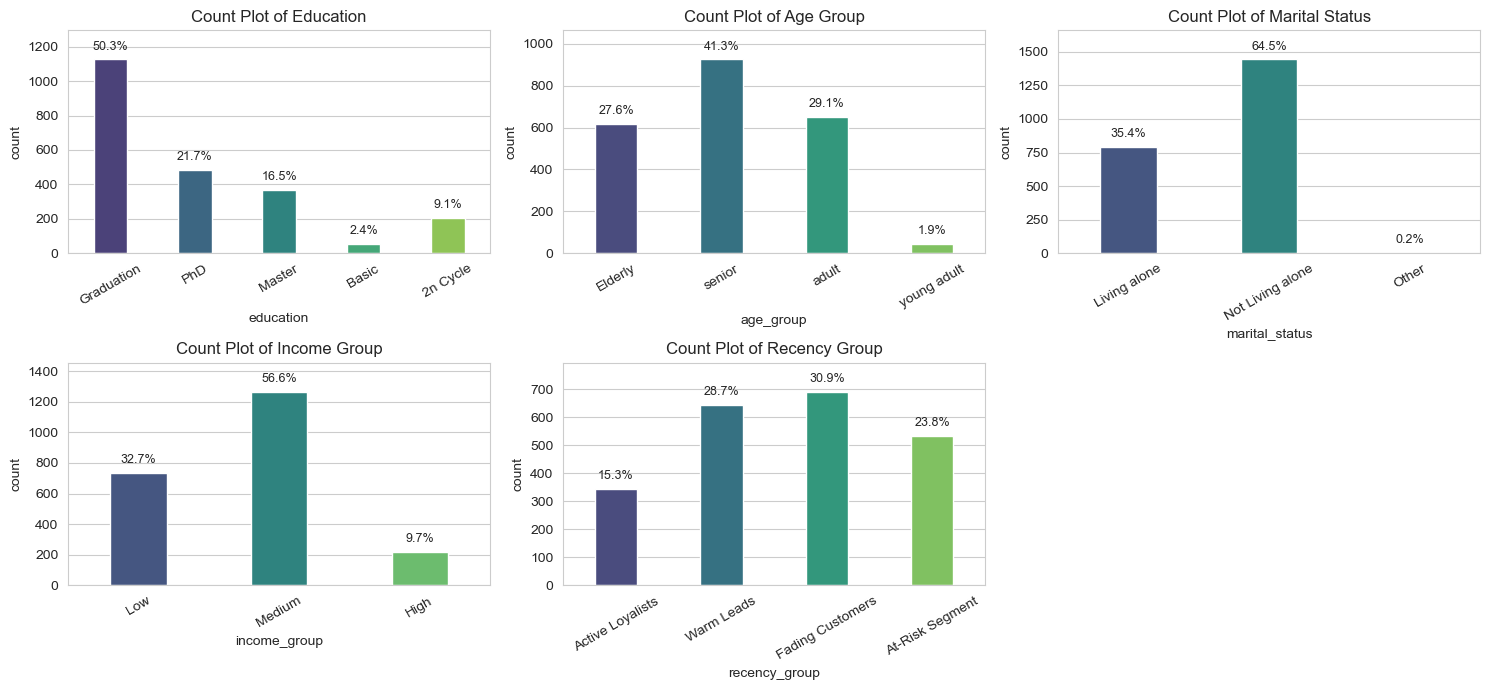

In [ ]:
#Analysing the distribution of features with categorical datatype
categorical_features_eda = ['education', 'age_group', 'marital_status', 'income_group', 'recency_group']

for col in categorical_features_eda:
    if data_eda[col].dtype.name == 'category':
        data_eda[col] = data_eda[col].cat.remove_unused_categories()

ncols = 3
nrows = -(-len(categorical_features_eda) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

# Plotting each categorical feature
for ax, col in zip(axes, categorical_features_eda):
    sns.countplot(data=data_eda, x=col, hue=col, dodge=False, palette='viridis', legend=False, ax=ax, width=0.4)
    ax.set_title(f"Count Plot of {col.replace('_', ' ').title()}")
    ax.tick_params(axis='x', rotation=30)

    total = len(data_eda)
    max_height = max([p.get_height() for p in ax.patches])
    ax.set_ylim(0, max_height * 1.15)

    for p in ax.patches:
        height = p.get_height()
        percent = 100 * height / total
        ax.annotate(f'{percent:.1f}%',
                    xy=(p.get_x() + p.get_width() / 2., height),
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)
for ax in axes[len(categorical_features_eda):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Observations:
**1. Education**
- 50.3% customers are graduated followed by PhD (21.7%) and Master (16.5%).
- Very few customers has Basic and 2n Cycle education.

**2. Age Group**
- There are majorly customers who are senior (41.3%).
- Only 1.9% are young adults which indicates there are very less younger customers.

**3. Marital Status**
- Majority of the customers (64.5%) are not living alone while almost negligible customers in other category.

**4. Income Group**
- 56.6% customers are earning medium income while only 9.7% customers are earning high.

**5. Recency Group**
- Most of the customers are Fading Customers (30.9%) who haven't interacted recently but were previously active.
- Active loyalists are 15.3% which means very small portion of customers are highly engaged.

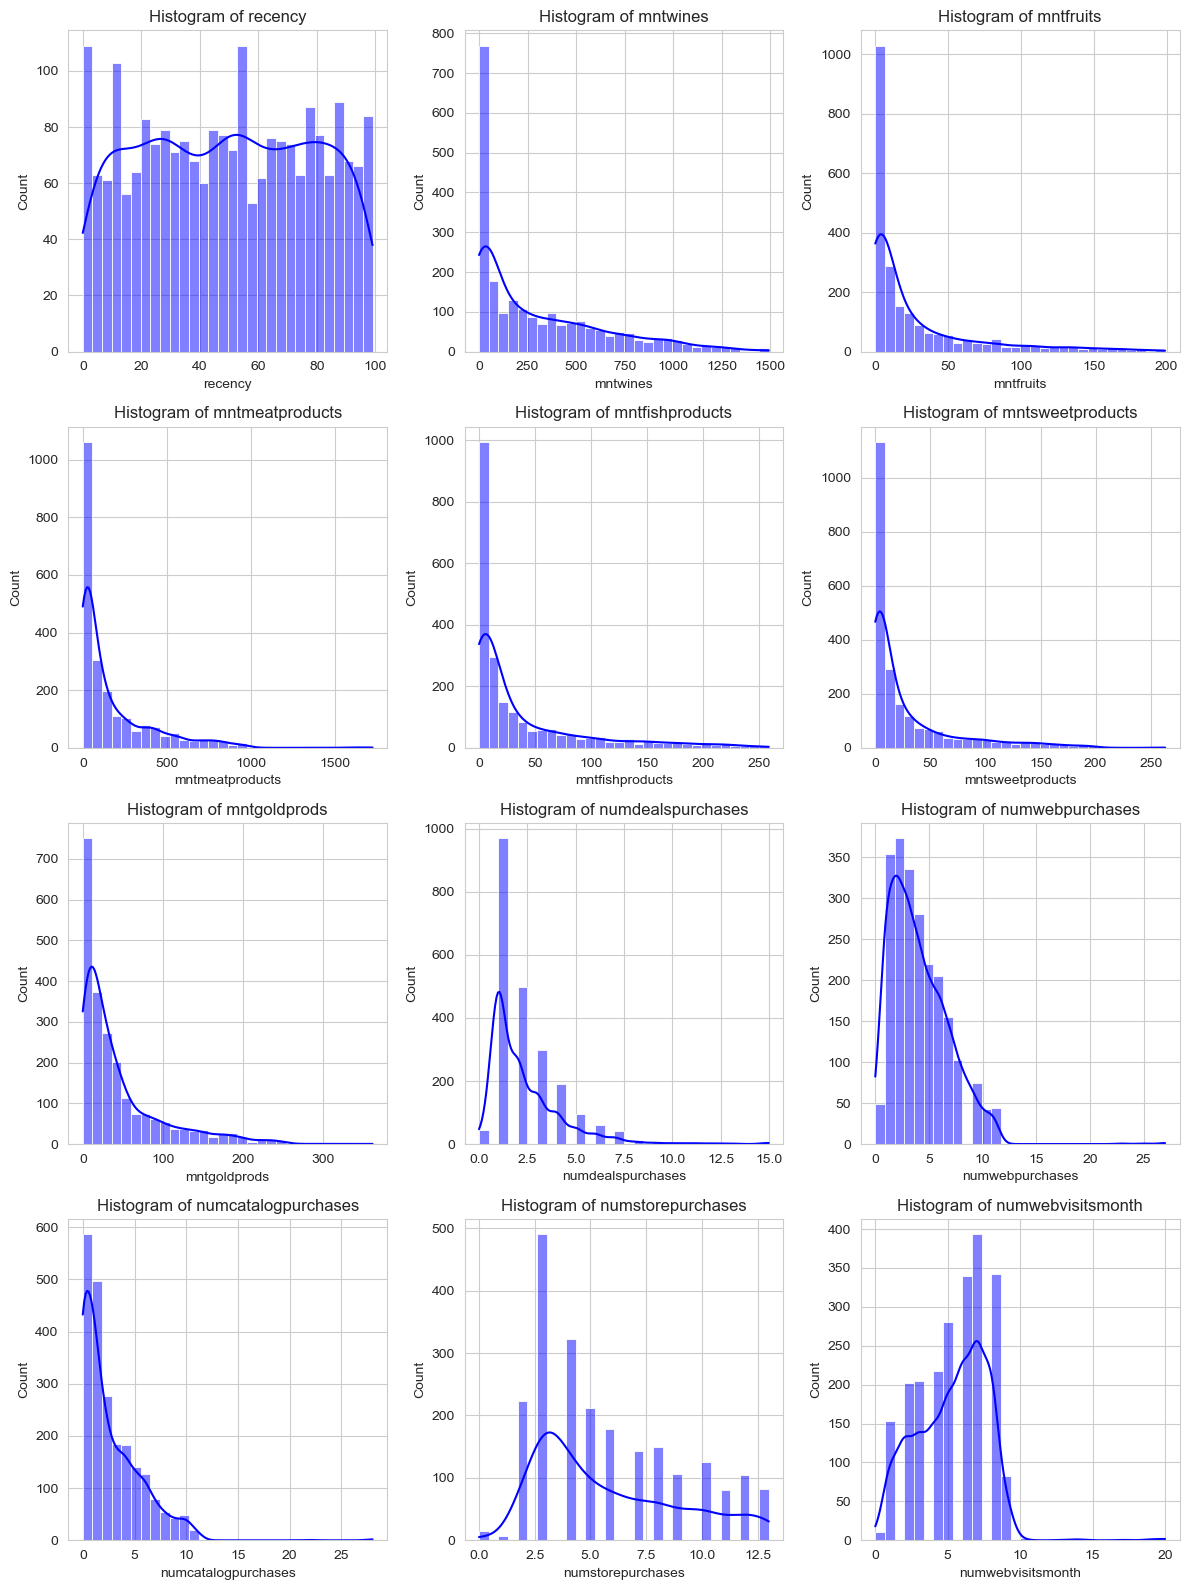

In [ ]:
#Analysing the distribution of features with numerical datatype
numerical_cols_eda = ['recency','mntwines','mntfruits','mntmeatproducts','mntfishproducts','mntsweetproducts',
                      'mntgoldprods','numdealspurchases','numwebpurchases','numcatalogpurchases','numstorepurchases','numwebvisitsmonth']

# Plotting 2 histograms per row
ncols = 3
nrows = -(-len(numerical_cols_eda) // ncols) 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

# Generating histogram in each subplot for each feature
for ax, col in zip(axes, numerical_cols_eda):
    sns.histplot(data_eda[col].dropna(), kde=True, bins=30, color='blue', ax=ax)
    ax.set_title(f"Histogram of {col}")
    ax.set_xlabel(col)


for ax in axes[len(numerical_cols_eda):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Observations:
- Most of the purchase related plots are right skewed which indicates that only few are spending high and most of the customers makes low purchases.
- Recency has uniform distribution which shows the balance between old and new customer interactions.
- Customer's web visits and web purchases are low which indicates that campaign should improve online engagement.
- Most customers are less engaged with channels like deal and catalog purchases which indicates they are less effective channels.
- Customers purchasing from store shows wider variation which shows customers prefers offline engagement and it could be targeted for in-store offers and promotions.

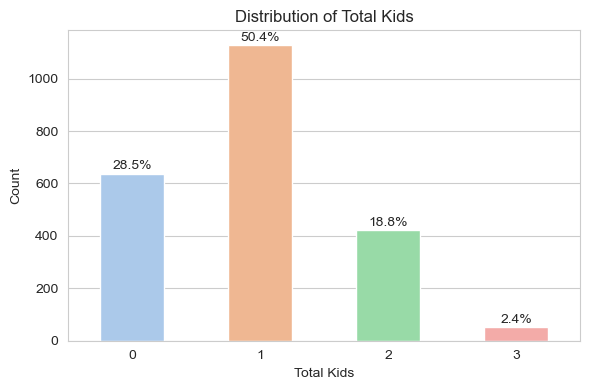

In [ ]:
#Analysing the distribution of totalkids feature
plt.figure(figsize=(6, 4))
sns.countplot(data=data_eda, x='totalkids', hue='totalkids', palette='pastel', legend=False, width=0.5)
total = len(data_eda)
for p in plt.gca().patches:
    height = p.get_height()
    percent = 100 * height / total
    plt.text(p.get_x() + p.get_width() / 2,
             height + 5,
             f'{percent:.1f}%',
             ha='center', va='bottom', fontsize=10)

plt.title('Distribution of Total Kids')
plt.xlabel('Total Kids')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Observations:
- Majority of the customers (50.4%) have 1 child at home which makes it the dominant category.
- 28.5% customers have no children at home.
- 18.8% customers have 2 kids and very few customers (2.4%) have 3 kids.
- We observe that nearly 80% of the customers have 0–1 child, so marketing campaigns should primarily target this segment for offers.

## Bivariate analysis

### Analysing how customer age group is influencing the likelihood to respond to marketing campaigns

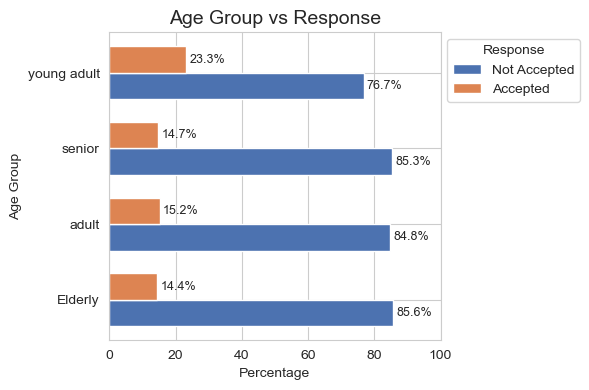

In [ ]:
#Calculating the percentage
percent_df = pd.crosstab(data_eda['age_group'], data_eda['response'], normalize='index') * 100
percent_df = percent_df.rename(columns={0: 'Not Accepted', 1: 'Accepted'}).fillna(0)

# Preparing plot configuration for display
age_groups = percent_df.index.tolist()
bar_height = 0.35
y = np.arange(len(age_groups))

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.barh(y - bar_height/2, percent_df['Not Accepted'], height=bar_height, label='Not Accepted', color='#4c72b0')
bars2 = ax.barh(y + bar_height/2, percent_df['Accepted'], height=bar_height, label='Accepted', color='#dd8452')

# Configuration for displaying text labels
for bars in [bars1, bars2]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontsize=9)

# Graph parameters to display
ax.set_title('Age Group vs Response', fontsize=14)
ax.set_xlabel('Percentage')
ax.set_ylabel('Age Group')
ax.set_yticks(y)
ax.set_yticklabels(age_groups)
ax.set_xlim(0, 100)
ax.legend(title='Response')

ax.legend(title='Response', loc='upper left', bbox_to_anchor=(1.0, 1))


plt.tight_layout()
plt.show()


### Observations:
- Young adults (23.3%) are more responsive to the market campaign offers.
- Adult, senior and elder customers have similar low acceptance rate while over 84% are not responding to the campaign.
- Younger customers are more engaged with the campaign.
- Campaigns should use some different strategies to engage more older adult groups.

#### Analysing customer complaint behavior whether it is affecting their likelihood of responding to marketing campaigns

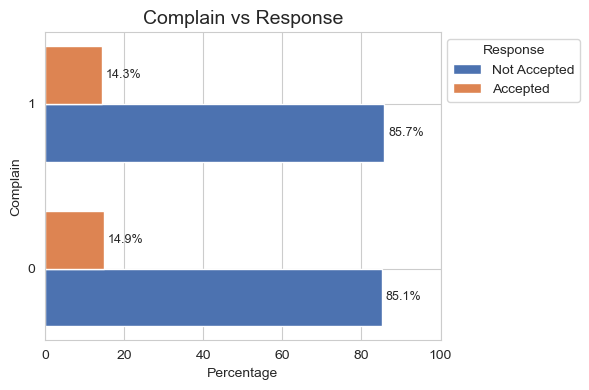

In [ ]:
 #Calculating percentage
percent_df = pd.crosstab(data_eda['complain'], data_eda['response'], normalize='index') * 100
percent_df = percent_df.rename(columns={0: 'Not Accepted', 1: 'Accepted'}).fillna(0)

# Preparing plot configuration for display
age_groups = percent_df.index.tolist()
bar_height = 0.35
y = np.arange(len(age_groups))

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.barh(y - bar_height/2, percent_df['Not Accepted'], height=bar_height, label='Not Accepted', color='#4c72b0')
bars2 = ax.barh(y + bar_height/2, percent_df['Accepted'], height=bar_height, label='Accepted', color='#dd8452')

#Configuration for displaying text labels
for bars in [bars1, bars2]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontsize=9)

#Graph parameters to display
ax.set_title('Complain vs Response', fontsize=14)
ax.set_xlabel('Percentage')
ax.set_ylabel('Complain')
ax.set_yticks(y)
ax.set_yticklabels(age_groups)
ax.set_xlim(0, 100)
ax.legend(title='Response')

ax.legend(title='Response', loc='upper left', bbox_to_anchor=(1.0, 1))


plt.tight_layout()
plt.show()


### Observations:
- Customers who complained have low acceptance rate compared to those who didn't.
- The difference in acceptance rates is very minimal which means complain factor is not affecting much for campaign response.

### Analysing the interaction of customers in recency group towards response

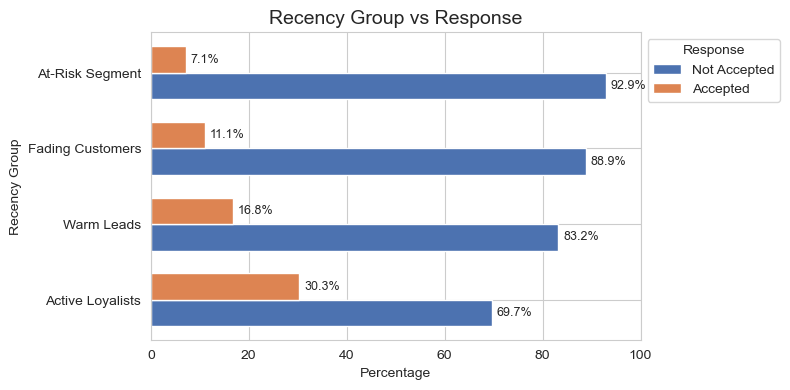

In [ ]:
# Calculating percentage
percent_df = pd.crosstab(data_eda['recency_group'], data_eda['response'], normalize='index') * 100
percent_df = percent_df.rename(columns={0: 'Not Accepted', 1: 'Accepted'}).fillna(0)

# Preparing plot configuration for display
age_groups = percent_df.index.tolist()
bar_height = 0.35
y = np.arange(len(age_groups))

fig, ax = plt.subplots(figsize=(8, 4))

bars1 = ax.barh(y - bar_height/2, percent_df['Not Accepted'], height=bar_height, label='Not Accepted', color='#4c72b0')
bars2 = ax.barh(y + bar_height/2, percent_df['Accepted'], height=bar_height, label='Accepted', color='#dd8452')

# Configuration for displaying text labels
for bars in [bars1, bars2]:
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontsize=9)

# Graph parameters to display
ax.set_title('Recency Group vs Response', fontsize=14)
ax.set_xlabel('Percentage')
ax.set_ylabel('Recency Group')
ax.set_yticks(y)
ax.set_yticklabels(age_groups)
ax.set_xlim(0, 100)
ax.legend(title='Response')

ax.legend(title='Response', loc='upper left', bbox_to_anchor=(1.0, 1))


plt.tight_layout()
plt.show()


### Observations:
- Active loyalists category achieves the highest acceptance rate of 30.3% which indicates that they are highly engaged with the market campaign.
- At-Risk Segment group have the lowest non-acceptance rate of 92.9% which means they need reactivation strategies.

#### Analysing whether prior campaign acceptance behavior influence the customers response to the current campaign

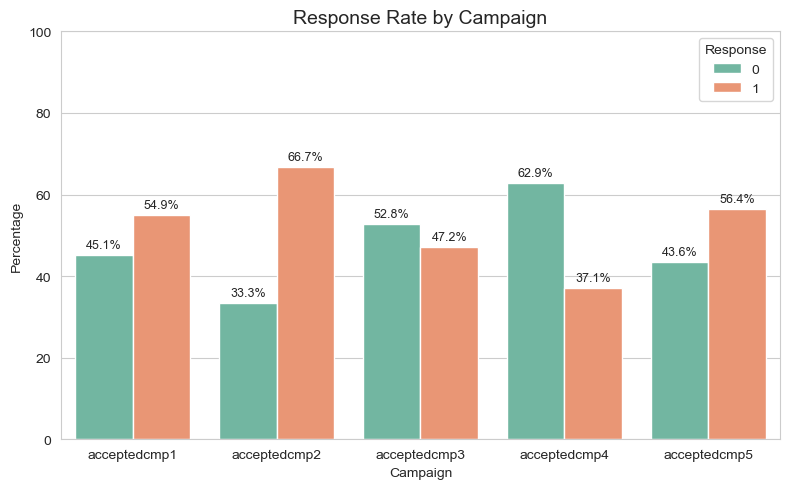

In [ ]:
cmp_cols = ['acceptedcmp1', 'acceptedcmp2', 'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5']
df_cmp = data_eda[cmp_cols + ['response']]

# Melting the values into long format for campaign(1-5), response, value (0 or 1)
df_melted = df_cmp.melt(id_vars='response', value_vars=cmp_cols,
                        var_name='Campaign', value_name='Accepted')

# Grouping and calculating percentage of response for accepted
grouped = df_melted[df_melted['Accepted'] == 1].groupby(['Campaign', 'response']).size().reset_index(name='count')

# Normalize to percentage within each campaign
total_per_campaign = grouped.groupby('Campaign')['count'].transform('sum')
grouped['percent'] = 100 * grouped['count'] / total_per_campaign

# Plotting grouped bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=grouped, x='Campaign', y='percent', hue='response', palette='Set2')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot parameters
ax.set_title('Response Rate by Campaign', fontsize=14)
ax.set_ylabel('Percentage')
ax.set_xlabel('Campaign')
ax.set_ylim(0, 100)
ax.legend(title='Response')
plt.tight_layout()
plt.show()

### Observations:
- Campaign2 achieves the highest acceptance rate of 66.7% while campaign4 has the highest non-acceptance rates of 62.9%.
- Campaign4 have the lowest acceptance rate of 37.1% which shows it's the least effective campaign among others.
- Campaign3 acceptance and non-acceptance rates are near which shows neutral performance.
- Campaign1 and campaign5 are also performing good having similar acceptance rates.

#### Analysing customers purchase behavior across different mode of purchases relate to their likelihood of responding to marketing campaigns

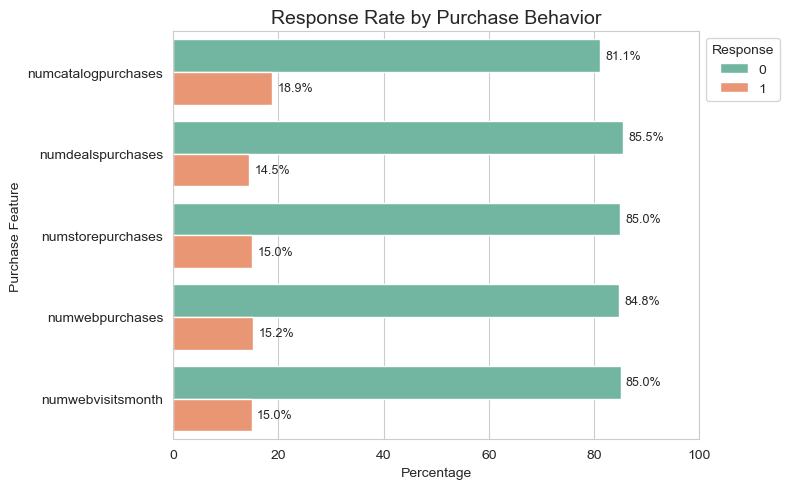

In [662]:
purch_cols = ['numdealspurchases','numwebpurchases','numcatalogpurchases','numstorepurchases','numwebvisitsmonth']
df_cmp = data_eda[purch_cols + ['response']]

# Melt into long format
df_melted = df_cmp.melt(id_vars='response', value_vars=purch_cols,
                        var_name='Campaign', value_name='Accepted')

# Only keep rows where Accepted > 0
df_melted = df_melted[df_melted['Accepted'] > 0]

# Group and compute percentages
grouped = df_melted.groupby(['Campaign', 'response']).size().reset_index(name='count')
grouped['percent'] = grouped.groupby('Campaign')['count'].transform(lambda x: 100 * x / x.sum())

# Plot horizontal bar chart
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=grouped, y='Campaign', x='percent', hue='response', palette='Set2')

# Add percentage labels
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(width + 1, p.get_y() + p.get_height()/2,
                f'{width:.1f}%', va='center', fontsize=9)

# Final formatting
ax.set_title('Response Rate by Purchase Behavior', fontsize=14)
ax.set_xlabel('Percentage')
ax.set_ylabel('Purchase Feature')
ax.set_xlim(0, 100)
ax.legend(title='Response', loc='upper left', bbox_to_anchor=(1.0, 1))
plt.tight_layout()
plt.show()

### Observations:
- Customers through catalog purchases are more responsive to the campaign with 18.9% acceptance rate.
- All the other channels except catalog purchase have low similar acceptance rates and non-acceptance rates.
- Overall, we can say that number of purchases frequency alone is not strongly influencing campaign acceptance.

#### Analysing the relationship between the number of website visits and the number of Web purchases made by customers?

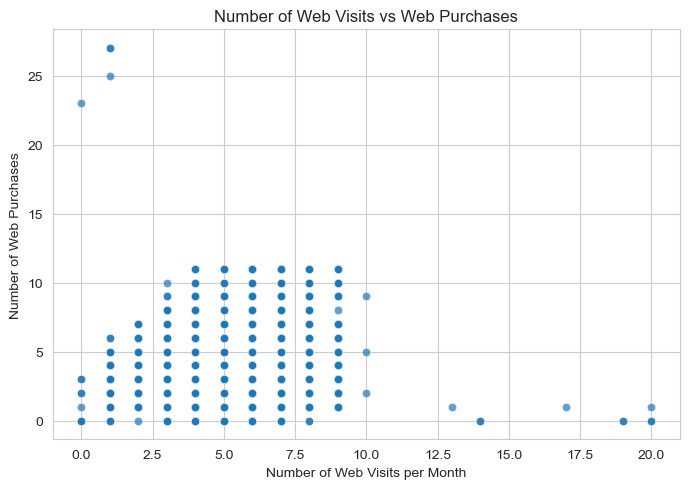

In [663]:

plt.figure(figsize=(7, 5))
sns.scatterplot(data=data_eda, x='numwebvisitsmonth', y='numwebpurchases', alpha=0.7)

plt.title('Number of Web Visits vs Web Purchases')
plt.xlabel('Number of Web Visits per Month')
plt.ylabel('Number of Web Purchases')
plt.grid(True)
plt.tight_layout()
plt.show()


### Observations:
- Majority of the customers are having 0-10 web visits per month.
- Few customers are making more web purchases having very low web visits.
- No strong linear relationship observed between number of web visits and number of web purchases which means that making more web visits doesn't mean making more purchases.

## Multivariate analysis

#### How does customer income levels and recency group together influence the marketing campaigns response?

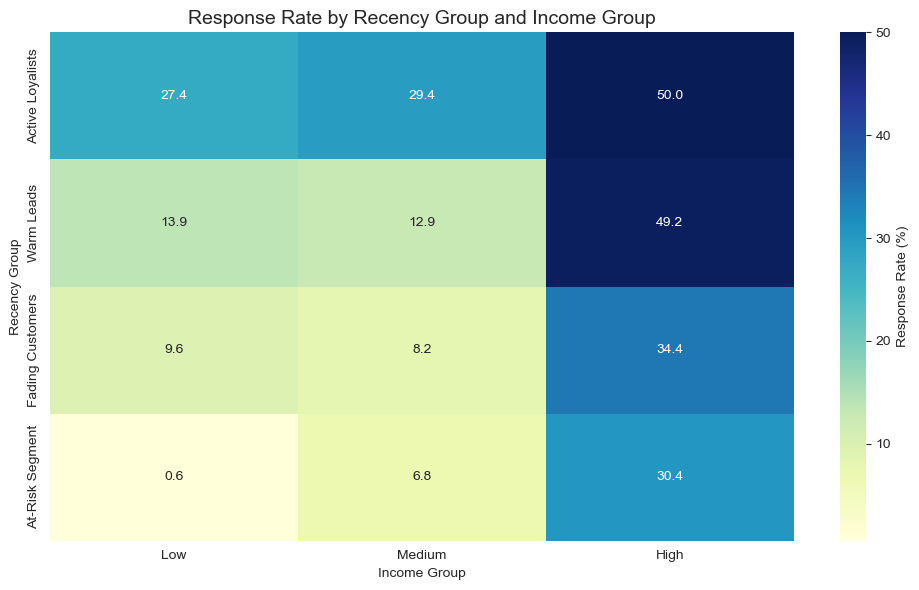

In [ ]:
# Creating a pivot table with percentage of responses
heatmap_data = data_eda.groupby(['recency_group', 'income_group'])['response'].mean().reset_index()
heatmap_data['response_percent'] = heatmap_data['response'] * 100

# Generating Heatmap for the pivot table created
pivot_table = heatmap_data.pivot(index='recency_group', columns='income_group', values='response_percent')

# Plotting heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Response Rate (%)'})

plt.title('Response Rate by Recency Group and Income Group', fontsize=14)
plt.xlabel('Income Group')
plt.ylabel('Recency Group')
plt.tight_layout()
plt.show()


### Observations:
- Active loyalists customers with high income have the highest response rate of 50% which indicates strong engagement.
- Customers having high income responds better to all the recency groups.
- Low income customers have the lowest acceptance rate of 0.6% for the At-Risk segment recency group.
- Active loyalists and warm leads with high income customers should be more prioritized by campaigns by focusing on personalized, multi-channel campaigns with exclusive offers and optimized timing.

#### How does customer income level impact response behavior across different modes of purchases?

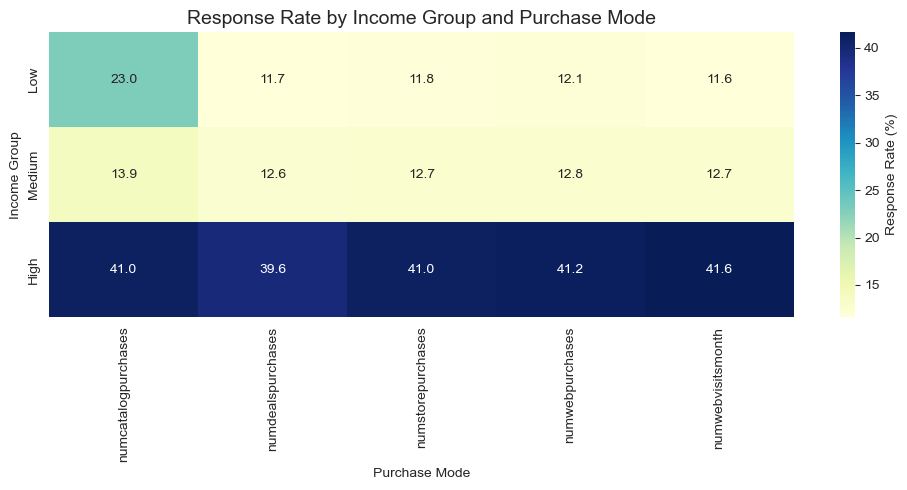

In [ ]:
purchase_modes = ['numdealspurchases', 'numwebpurchases', 'numcatalogpurchases', 
                  'numstorepurchases', 'numwebvisitsmonth']

df_cmp = data_eda[purchase_modes + ['income_group', 'response']].copy()

# Creating a pivot table with percentage of responses
df_melted = df_cmp.melt(id_vars=['income_group', 'response'],
                        value_vars=purchase_modes,
                        var_name='Purchase_Mode', value_name='Value')

# Filtering rows where the mode was actually used (Value > 0)
df_melted = df_melted[df_melted['Value'] > 0]

# Grouping and computing percentage of response within each income and purchase mode
grouped = df_melted.groupby(['income_group', 'Purchase_Mode'])['response'].mean().reset_index()
grouped['response_percent'] = grouped['response'] * 100

# Generating Heatmap for the pivot table created
pivot_table = grouped.pivot(index='income_group', columns='Purchase_Mode', values='response_percent')

# Plotting heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Response Rate (%)'})

plt.title('Response Rate by Income Group and Purchase Mode', fontsize=14)
plt.xlabel('Purchase Mode')
plt.ylabel('Income Group')
plt.tight_layout()
plt.show()

### Observations:
- Customers having high income with higher web visit frequency achieves the highest acceptance rate of 41.6%.
- Customers having high income shows the consistent performance across all the purchase modes having acceptance rate around 41%.
- Medium income customers have similar and low acceptance rate across all purchase modes.
- Customers having low income respond best through catalog purchase with rate of 23%.
- Campaigns should focus marketing efforts on high-income customers with frequent web visits and leverage personalized digital campaigns.

#### Analysing customers prior engagement with previous campaigns whether it will increase the likelihood of them responding to new campaigns

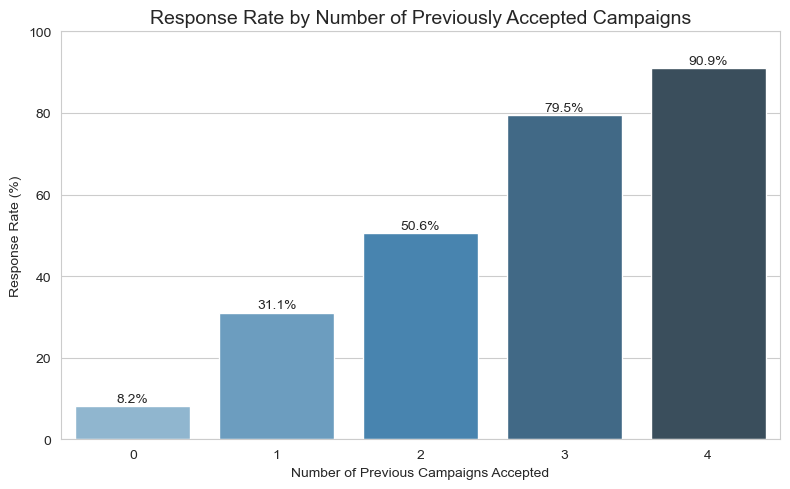

In [ ]:
data_eda['total_previous_accepts'] = data_eda[cmp_cols].sum(axis=1)

# Group and calculate response rate
grouped = data_eda.groupby('total_previous_accepts')['response'].mean().reset_index()
grouped['response_percent'] = grouped['response'] * 100

# Plot the graph
plt.figure(figsize=(8, 5))
sns.barplot(data=grouped, x='total_previous_accepts', y='response_percent', palette='Blues_d')

# Adding annotations
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.1f}%', ha='center', fontsize=10)

# Graph parameters
plt.title('Response Rate by Number of Previously Accepted Campaigns', fontsize=14)
plt.xlabel('Number of Previous Campaigns Accepted')
plt.ylabel('Response Rate (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Observations:
- With number of previously accepted campaigns are increasing with response rate.
- Customers who never accepted previous campaigns respond with only 8.2% while those with 4 accepted previously campaigns respond at 90.9%.
- Prioritize customers who accepted campaigns previously as they shows the high probability to respond again. We can use reward strategy to retain the customers.

#### Analysing how does customer age_group and income_group levels jointly influence their response rate to marketing campaigns

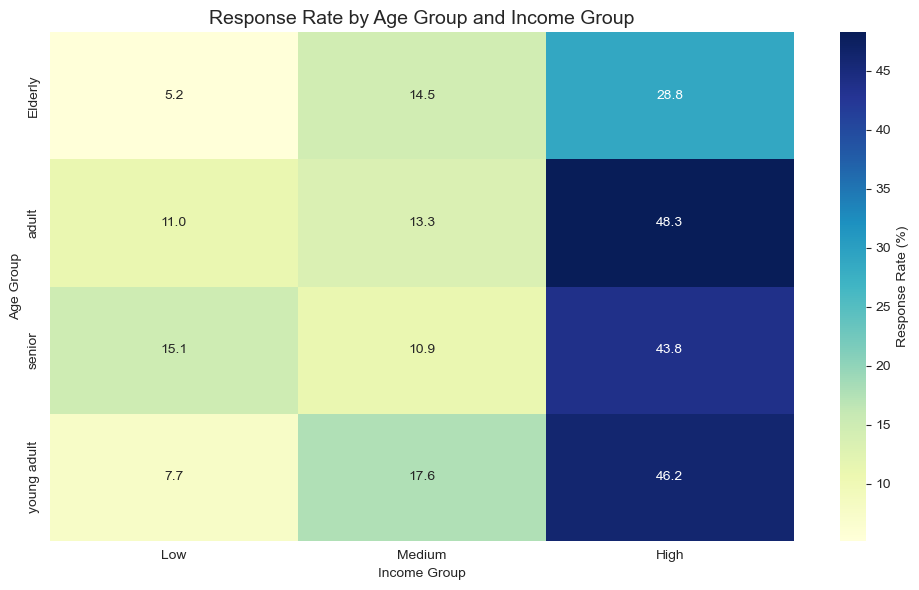

In [ ]:
# Grouping and calculating response rate
heatmap_data = data_eda.groupby(['age_group', 'income_group'])['response'].mean().reset_index()
heatmap_data['response_percent'] = heatmap_data['response'] * 100

# Pivot table for heatmap
pivot_table = heatmap_data.pivot(index='age_group', columns='income_group', values='response_percent')

# Plotting heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Response Rate (%)'})

plt.title('Response Rate by Age Group and Income Group', fontsize=14)
plt.xlabel('Income Group')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

### Observations:
- Adult customers with high income achieves the highest acceptance rate of 48.3%.
- Low income customers shows the lowest acceptance rates across all the age groups especially the elder customers with 5.2% rate.
- Young adult customers having medium income respond better with 17.6% compared to other age groups.
- Focus campaigns on high income adults and seniors as they show the highest response potential and avoid heavy marketing spend on low income and elderly segments.

#### Analysing how do a customer marital status and education level together impact their likelihood of responding to marketing campaigns

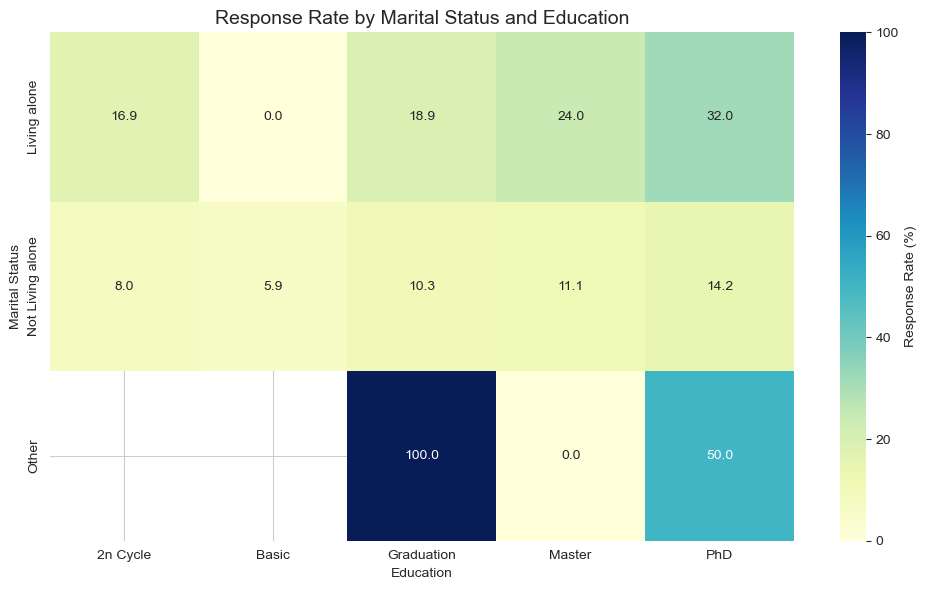

In [669]:
# Step 1: Group and calculate response rate
heatmap_data = data_eda.groupby(['marital_status', 'education'])['response'].mean().reset_index()
heatmap_data['response_percent'] = heatmap_data['response'] * 100

# Step 2: Pivot for heatmap
pivot_table = heatmap_data.pivot(index='marital_status', columns='education', values='response_percent')

# Step 3: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Response Rate (%)'})

plt.title('Response Rate by Marital Status and Education', fontsize=14)
plt.xlabel('Education')
plt.ylabel('Marital Status')
plt.tight_layout()
plt.show()

### Observations:
- Customers living alone with master and phd education show higher acceptance rates.
- Customers who are not living alone shows the low acceptance rate under 15% across all the education groups.
- Graduates customers living alone respond at 18.9% while those who are not living alone responds at 10.3%.
- The other marital status shows the extreme response rate of 100% for graduation, 50% for phd and 0% elsewhere might be due to small sample size.

## Data Preprocessing

### Analysing the distribution of income feature to perform imputation method

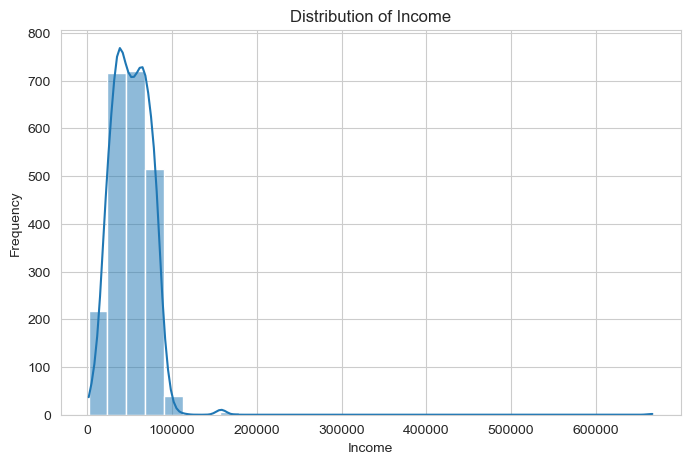

In [670]:
plt.figure(figsize=(8, 5))
sns.histplot(data['income'], bins=30, kde=True)
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

We could see the distribution of feature income is skewed and hence we are performing median imputation as it preserves the data distribution

In [ ]:
print("Missing values before for feature income:", data['income'].isna().sum())

# Imputing feature income
data['income'] = data['income'].fillna(data['income'].median())

print("Missing values after for feature income:", data['income'].isna().sum())

Missing values before for feature income: 24
Missing values after for feature income: 0


## Correlation analysis

In [ ]:
# Splitting the features into numerical and categorical
categorical_features = data.select_dtypes(include=['object']).columns
numeric_features = data.select_dtypes(include=['float64', 'int64']).columns
print("Categorical columns are:",categorical_features)
print("Numerical columns are:",numeric_features)

Categorical columns are: Index(['education', 'marital_status', 'dt_customer'], dtype='object')
Numerical columns are: Index(['year_birth', 'income', 'kidhome', 'teenhome', 'recency', 'mntwines',
       'mntfruits', 'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'complain', 'response'],
      dtype='object')


## Performing correlation analysis on numerical features

In [ ]:
corr = data[numeric_features].corr(method='pearson')

# Generate the correlation matrix for numeric features with absolute correlation value
corr_matrix = corr.abs() 

# Create a mask to ignore self-correlations
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Finding pairs with correlation greater than 0.8
high_corr_pairs = upper_triangle.stack().reset_index()
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.8]

#Displaying the result
print(high_corr_pairs.sort_values(by='Correlation', ascending=False))


Empty DataFrame
Columns: [Feature 1, Feature 2, Correlation]
Index: []


we could see that none of the numerical features are highly correlated.

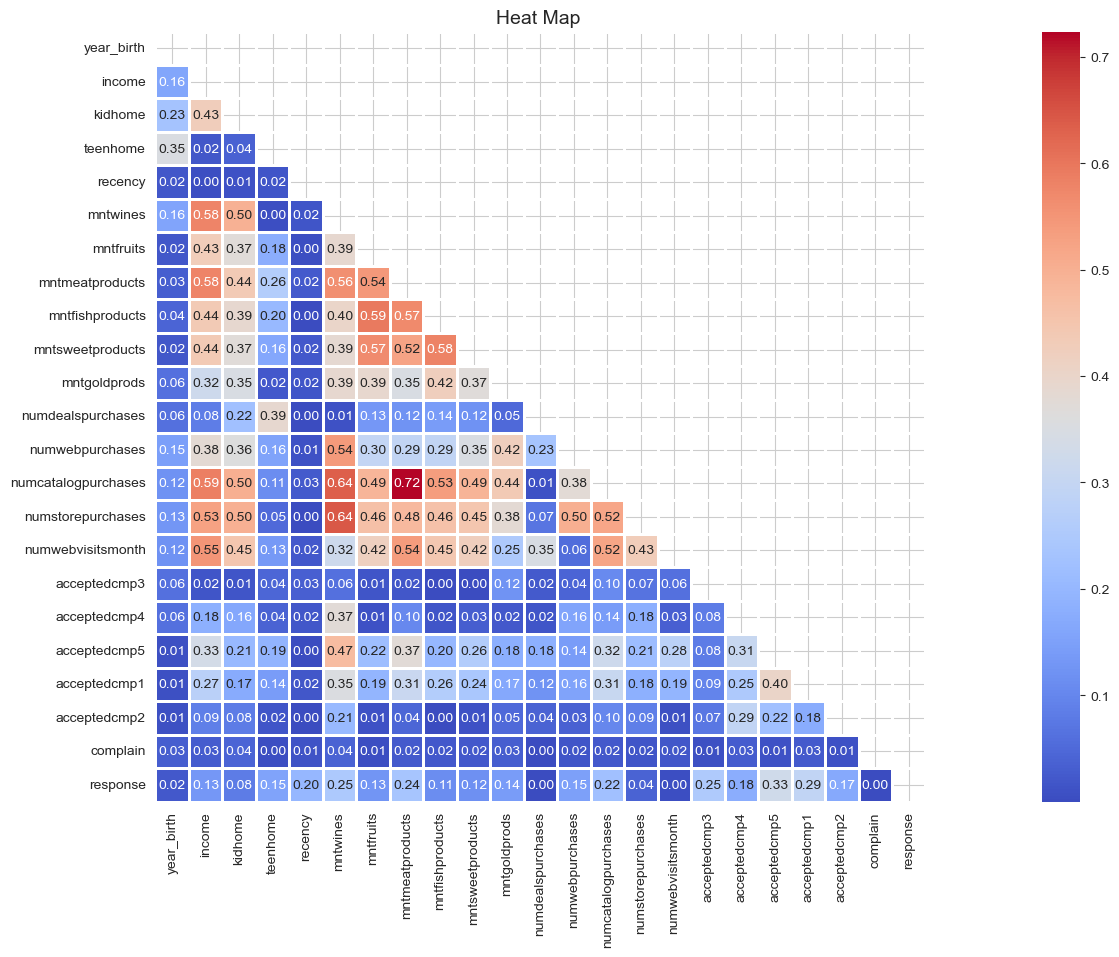

In [674]:
# Mask upper triangle correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting heat map with only lower triangular part of correlation matrix 
plt.figure(figsize=(30, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, square=True, cbar=True)

plt.title("Heat Map ", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

## Cramers V to analyse the association between the categorical features

In [675]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

cramer_results = []
for col1 in categorical_features:
    for col2 in categorical_features:
        if col1 != col2:
            score = cramers_v(data[col1], data[col2])
            print(f"Cramér's V between {col1} and {col2}: {score:.2f}")
            cramer_results.append((col1, col2, round(score, 4)))

cramer_df = pd.DataFrame(cramer_results, columns=['Feature 1', 'Feature 2', "Cramér's V"])

print("High Cramér’s V associations between nominal categorical columns (V > 0.8):")
print(cramer_df[cramer_df["Cramér's V"] > 0.8])

Cramér's V between education and marital_status: 0.06
Cramér's V between education and dt_customer: 0.59
Cramér's V between marital_status and education: 0.06
Cramér's V between marital_status and dt_customer: 0.55
Cramér's V between dt_customer and education: 0.59
Cramér's V between dt_customer and marital_status: 0.55
High Cramér’s V associations between nominal categorical columns (V > 0.8):
Empty DataFrame
Columns: [Feature 1, Feature 2, Cramér's V]
Index: []


We could see that none of the categorical features are highly associated.

## Feature Engineering for modeling

In [676]:
data.head()

,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


In [677]:
#Converting the year of birth column to age by taking today's year as consideration
current_year = datetime.now().year
print(f'current year is : {current_year}')

data['age'] = current_year - data['year_birth']
data = data.drop('year_birth', axis=1)
data.head()


current year is : 2025


,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age
0,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,68
1,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,71
2,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,60
3,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,41
4,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,44


In [678]:
#performing feature engineering on feature marital_status

data.loc[(data['marital_status'] == 'Single') | 
         (data['marital_status'] == 'Divorced') | 
         (data['marital_status'] == 'Widow') | 
         (data['marital_status'] == 'Alone'), 'marital_status'] = 'Living alone'

data.loc[(data['marital_status'] == 'Together') | 
         (data['marital_status'] == 'Married'), 'marital_status'] = 'Not Living alone'

data.loc[(data['marital_status'] == 'Absurd') | 
         (data['marital_status'] == 'YOLO'), 'marital_status'] = 'Other'

In [679]:
#combining feature kidhome and teenhome
data['totalkids'] = data['kidhome'] + data['teenhome']

In [680]:
# Convert to datetime
data['dt_customer'] = pd.to_datetime(data['dt_customer'])

# Calculate years enrolled
today = pd.to_datetime("today")
data['years_enrolled'] = ((today - data['dt_customer']).dt.days / 365).astype(int)

data = data.drop('dt_customer', axis=1)

In [681]:
data.head()

,education,marital_status,income,kidhome,teenhome,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,totalkids,years_enrolled
0,Graduation,Living alone,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,68,0,12
1,Graduation,Living alone,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,71,2,11
2,Graduation,Not Living alone,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,60,0,11
3,Graduation,Not Living alone,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,41,1,11
4,PhD,Not Living alone,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,44,1,11


## Outliers identification

In [ ]:
outliers_num = ['age', 'income', 'totalkids', 'recency', 'mntwines', 'mntfruits', 'mntmeatproducts', 'mntfishproducts', 
                'mntsweetproducts', 'mntgoldprods', 'numdealspurchases', 'numwebpurchases', 'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth','years_enrolled']
# Calculating the IQR
Q1 = data[outliers_num].quantile(0.25)
Q3 = data[outliers_num].quantile(0.75)
IQR = Q3 - Q1

# Defining the boundaries (upper limit and lower limit to filter out the outliers)
outlier_mask = (data[outliers_num] < (Q1 - 1.5 * IQR)) | (data[outliers_num] > (Q3 + 1.5 * IQR))

# Counting the number of outliers in each numerical feature
outlier_counts = outlier_mask.sum()

print("Number of outliers detected using the IQR method:")
print(outlier_counts)

Number of outliers detected using the IQR method:
age                      3
income                   8
totalkids               53
recency                  0
mntwines                35
mntfruits              227
mntmeatproducts        175
mntfishproducts        223
mntsweetproducts       248
mntgoldprods           207
numdealspurchases       86
numwebpurchases          4
numcatalogpurchases     23
numstorepurchases        0
numwebvisitsmonth        8
years_enrolled           0
dtype: int64


We are not handling the outliers as tree based models are not sensitive for the outliers present in the data set

In [683]:
data_model = data.copy()

In [684]:
data_model.head()

,education,marital_status,income,kidhome,teenhome,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,totalkids,years_enrolled
0,Graduation,Living alone,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,68,0,12
1,Graduation,Living alone,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,71,2,11
2,Graduation,Not Living alone,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,60,0,11
3,Graduation,Not Living alone,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,41,1,11
4,PhD,Not Living alone,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,44,1,11


Dropping feature 'kidhome' and 'teenhome' as we have combined them into feature 'totalkids'

In [685]:
data_model = data_model.drop('kidhome', axis=1)

In [686]:
data_model = data_model.drop('teenhome', axis=1)

In [687]:
data_model.head()

,education,marital_status,income,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,totalkids,years_enrolled
0,Graduation,Living alone,58138.0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,68,0,12
1,Graduation,Living alone,46344.0,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,71,2,11
2,Graduation,Not Living alone,71613.0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,60,0,11
3,Graduation,Not Living alone,26646.0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,41,1,11
4,PhD,Not Living alone,58293.0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,44,1,11


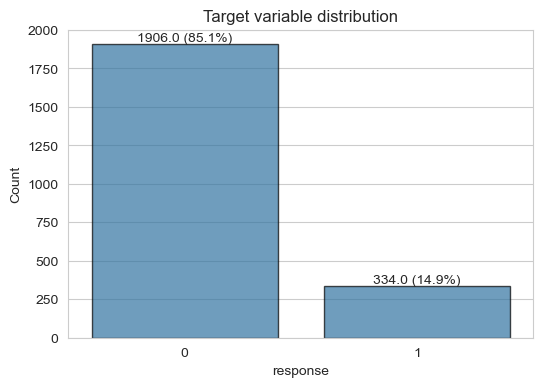

In [ ]:
#Analysing the distribution of classes in the target feature
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=data['response'], edgecolor='k', alpha=0.7)
plt.title('Target variable distribution')
plt.xlabel('response')
plt.ylabel('Count')

total = len(data['response'])

for p in ax.patches:
    count = p.get_height()
    percent = 100 * count / total
    ax.annotate(f'{count} ({percent:.1f}%)',
                (p.get_x() + p.get_width() / 2, count), 
                ha='center', va='bottom', fontsize=10)

plt.show()


Target feature is highly imbalanced with 85.1% negative classes and 14.9% positive classes, need to balanced the data set before model building.

In [689]:
data_model.head()

,education,marital_status,income,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,complain,response,age,totalkids,years_enrolled
0,Graduation,Living alone,58138.0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,68,0,12
1,Graduation,Living alone,46344.0,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,71,2,11
2,Graduation,Not Living alone,71613.0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,60,0,11
3,Graduation,Not Living alone,26646.0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,41,1,11
4,PhD,Not Living alone,58293.0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,44,1,11


### Seperating the features and target variable

In [690]:
## Splitting features and target variable 
X = data_model.drop('response', axis=1)  
y = data_model['response']             

In [ ]:
#Splitting the numerical and categorical features
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns
print("Categorical columns are:",categorical_cols)
print("Numerical columns are:",numeric_cols)

Categorical columns are: Index(['education', 'marital_status'], dtype='object')
Numerical columns are: Index(['income', 'recency', 'mntwines', 'mntfruits', 'mntmeatproducts',
       'mntfishproducts', 'mntsweetproducts', 'mntgoldprods',
       'numdealspurchases', 'numwebpurchases', 'numcatalogpurchases',
       'numstorepurchases', 'numwebvisitsmonth', 'acceptedcmp3',
       'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1', 'acceptedcmp2',
       'complain', 'age', 'totalkids'],
      dtype='object')


## Logistic Regression

In [692]:
X_lr = X.copy()
y_lr = y.copy()

## One hot encoding for categorical features

In [693]:

# Performing one hot encoding for the columns with object data type
X_lr_ec = pd.get_dummies(X_lr[categorical_cols], drop_first=True)

# Dropping the original categorical columns from the main data
X_lr.drop(columns=categorical_cols, inplace=True)

# Adding the encoded columns to the main data
X_lr = pd.concat([X_lr, X_lr_ec], axis=1)


## Splitting the data set

In [694]:
# Splitting the dataset into training (80%) and testing (20%)
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=25, stratify=y)

In [695]:
# Check class distribution of target variable before applying SMOTE
print("Original Training Class Distribution:", y_train_lr.value_counts())

Original Training Class Distribution: response
0    1525
1     267
Name: count, dtype: int64


## Scaling the numerical features

In [696]:


# Performing Min-Max scaling on Training data set
scaler = MinMaxScaler()
X_train_lr[numeric_cols] = scaler.fit_transform(X_train_lr[numeric_cols])

# Transforming the testing data set using the same scaler
X_test_lr[numeric_cols]= scaler.transform(X_test_lr[numeric_cols])


In [697]:
#Performing SMOTE Operation on training data set to handle data imbalance issue

# Applying SMOTE only on the training dataset
smote = SMOTE(random_state=10)
X_train_lr_rs, y_train_lr_rs = smote.fit_resample(X_train_lr, y_train_lr)

# Check class distribution after SMOTE
print("Resampled Training Class Distribution:", y_train_lr_rs.value_counts())

Resampled Training Class Distribution: response
0    1525
1    1525
Name: count, dtype: int64


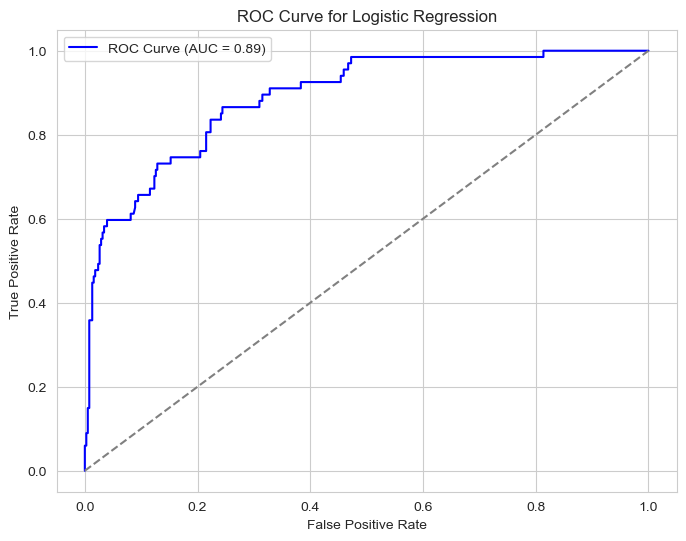


Logistic Regression Model Performance on Resampled Data:
Accuracy: 0.7902
Precision: 0.8643
Recall: 0.7902
F1-Score: 0.8137
AUC Score: 0.8897


In [698]:

# Fitting logistic regression model with balanced data set
log_reg = LogisticRegression(class_weight='balanced', random_state=50, max_iter=1000)
log_reg.fit(X_train_lr_rs, y_train_lr_rs)

# Predicting the target values
y_pred_lr = log_reg.predict(X_test_lr)
y_prob_lr = log_reg.predict_proba(X_test_lr)[:, 1]


# calculating the performance metrics to analyse models performance
accuracy_lr = accuracy_score(y_test_lr, y_pred_lr)
precision_lr = precision_score(y_test_lr, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test_lr, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test_lr, y_pred_lr, average='weighted')


# Computing ROC curve and AUC score
fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', label=f'ROC Curve (AUC = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()

print("\nLogistic Regression Model Performance on Resampled Data:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"AUC Score: {roc_auc_lr:.4f}")

Logistic Regression model achieved an accuracy (0.7902), precision (0.8643), recall (0.7902), F1-score (0.8137), and an AUC score (0.8897), indicating a strong balance between precision and recall with high discriminatory power.

In [700]:
#Gettting the top 3 most influential features

feature_names_lr = X_train_lr.columns

# Fetching the coefficients
coefficients_lr = log_reg.coef_[0]

# Creating a DataFrame to perform sorting of the features
coef_df_lr = pd.DataFrame({
    'Feature': feature_names_lr,
    'Coefficient': coefficients_lr,
    'Abs_Coefficient': np.abs(coefficients_lr)
})

# Fetching top 3 features coefficients
top_features_lr = coef_df_lr.sort_values(by='Abs_Coefficient', ascending=False).head(3)

print("Top 3 most influential features (by absolute coefficient):")
print(top_features_lr[['Feature', 'Coefficient']])


Top 3 most influential features (by absolute coefficient):
              Feature  Coefficient
1             recency    -3.628788
4     mntmeatproducts     3.397644
11  numstorepurchases    -3.015930


We could see that features like recency, mntmeatproducts and numstorepurchases are the highest contributers for the Decision Tree model performance.

## Decision tree

In [701]:
# Splitting the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1025, stratify=y)

# Check class distribution of target variable before applying SMOTE
print("Original Training Class Distribution:", y_train.value_counts())

Original Training Class Distribution: response
0    1525
1     267
Name: count, dtype: int64


In [702]:
#Apply Label Encoding for the categorical features
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

### Handling imabalance issue

In [703]:
#Applying SMOTENC to handle the data imbalance

cat_features_indices = [X_train.columns.get_loc(col) for col in categorical_cols]
smote_nc = SMOTENC(categorical_features=cat_features_indices, random_state=42)
X_train_rs, y_train_rs = smote_nc.fit_resample(X_train, y_train)

# Checking class distribution after SMOTE
print("Resampled Training Class Distribution:", y_train_rs.value_counts())


Resampled Training Class Distribution: response
0    1525
1    1525
Name: count, dtype: int64


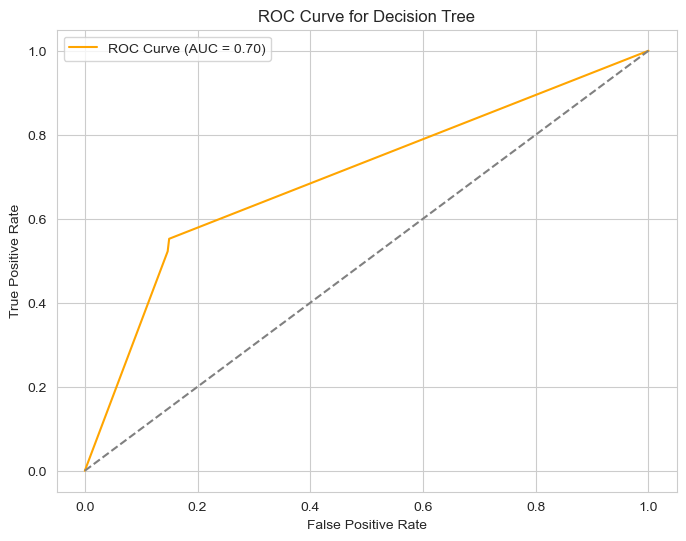


Decision Tree Model Performance:
Accuracy: 0.8036
Precision: 0.8317
Recall: 0.8036
F1-Score: 0.8153
AUC Score: 0.6998


In [ ]:
# Initializing Decision Tree model
model_dt = DecisionTreeClassifier(
    max_depth=None,             
    class_weight='balanced',  
    random_state=42
)

# Train the model
model_dt.fit(X_train_rs, y_train_rs)

# Predict the target values
y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

# Performance metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

# ROC Curve and AUC value
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='orange', label=f'ROC Curve (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree')
plt.legend()
plt.show()

# Displaying the performance metrics
print("\nDecision Tree Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"AUC Score: {roc_auc_dt:.4f}")


1) Decision Tree model achieved an accuracy (0.8036), precision (0.8317), recall (0.8036) and F1-score (0.8153) which indicates a moderate overall performance.

2) AUC score (0.6998) suggests the model has limited capability in distinguishing between the two classes, indicating scope for improvement in discriminatory power.

In [705]:
# Getting top 3 important features for Decision Tree model
feature_names = X_train.columns

# Extract feature importances
importances_dt = model_dt.feature_importances_

# Create a DataFrame to sort by importance
importance_df_dt = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_dt
})

# Sort and get top 3 features
top_3_features_dt = importance_df_dt.sort_values(by='Importance', ascending=False).head(3)

print("Top 3 most important features in Decision Tree:")
print(top_3_features_dt)


Top 3 most important features in Decision Tree:
         Feature  Importance
22     totalkids    0.134871
3        recency    0.131613
9   mntgoldprods    0.089429


We could see that features like recency, totalkids and mntgoldprods are the highest contributers for the Decision Tree model performance.

## Random Forest

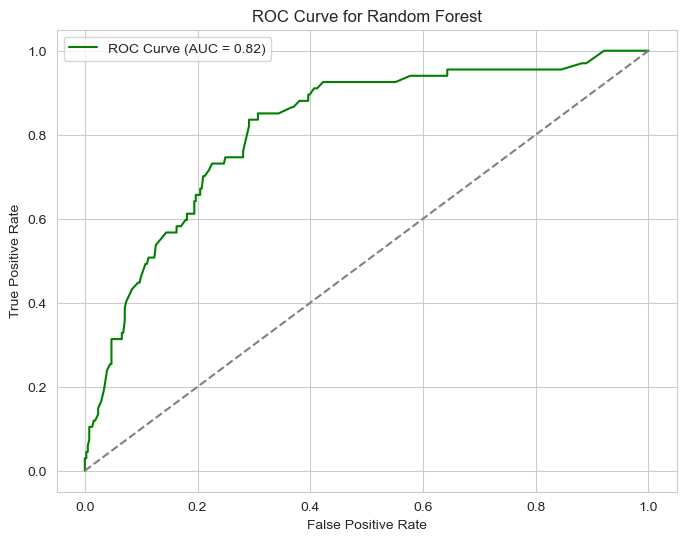


Random Forest Model Performance:
Accuracy: 0.8281
Precision: 0.8398
Recall: 0.8281
F1-Score: 0.8334
AUC Score: 0.8151


In [706]:
model_rf = RandomForestClassifier(
    n_estimators=100,   
    max_depth=None,       
    max_features='sqrt',     
    class_weight='balanced',
    random_state=42
)

#Training the model
model_rf.fit(X_train_rs, y_train_rs)

# Predicting the target values
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1] 

# Performance metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

#ROC Curve and AUC values
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', label=f'ROC Curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest')
plt.legend()
plt.show()

# Displaying the performance metrics
print("\nRandom Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"AUC Score: {roc_auc_rf:.4f}")

1) Model shows strong performance with an accuracy (0.8281), precision (0.8398), recall (0.8281), F1-score (0.8334) and AUC score (0.8151), indicating well-balanced classification capabilities

2) ROC curve indicates good classification ability, maintaining a balance between sensitivity and specificity.

In [707]:

#Fetching top 3 important features
importances_rf = model_rf.feature_importances_

#Creating a DataFrame for sorting the values
importance_df_rf = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_rf
})

top_3_features_rf = importance_df_rf.sort_values(by='Importance', ascending=False).head(3)

print("Top 3 most important features in Random Forest:")
print(top_3_features_rf)


Top 3 most important features in Random Forest:
        Feature  Importance
3       recency    0.121361
2        income    0.092568
9  mntgoldprods    0.089958


We could see that features like recency, income and mntgoldprods are the highest contributers for the Randome Forest model performance.

## XGBoost

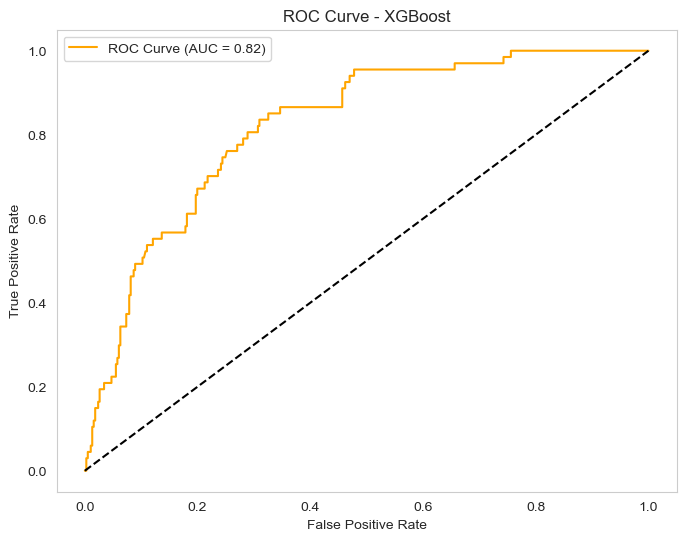


XGBoost Model Performance:
Accuracy:  0.7768
Precision: 0.8399
Recall:    0.7768
F1-Score:  0.7993
AUC Score: 0.8220


In [708]:
model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss', 
    random_state=1025
)

#Training the model
model_xgb.fit(X_train_rs, y_train_rs)

# Predicting the target values
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

# Model Performance metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test, y_pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

# ROC & AUC value
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'ROC Curve (AUC = {roc_auc_xgb:.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid()
plt.show()

# Displaying the performance metrics
print("\nXGBoost Model Performance:")
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall:    {recall_xgb:.4f}")
print(f"F1-Score:  {f1_xgb:.4f}")
print(f"AUC Score: {roc_auc_xgb:.4f}")

1) Model shows decent performance with Accuracy (0.7768), Precision (0.83.99), Recall (0.7768) and F1-Score (0.7993) which indicates a good balance between precision and recall.

2) AUC Score (0.8220) as shown in the ROC Curve indicates strong discriminatory power in distinguishing between the two classes.

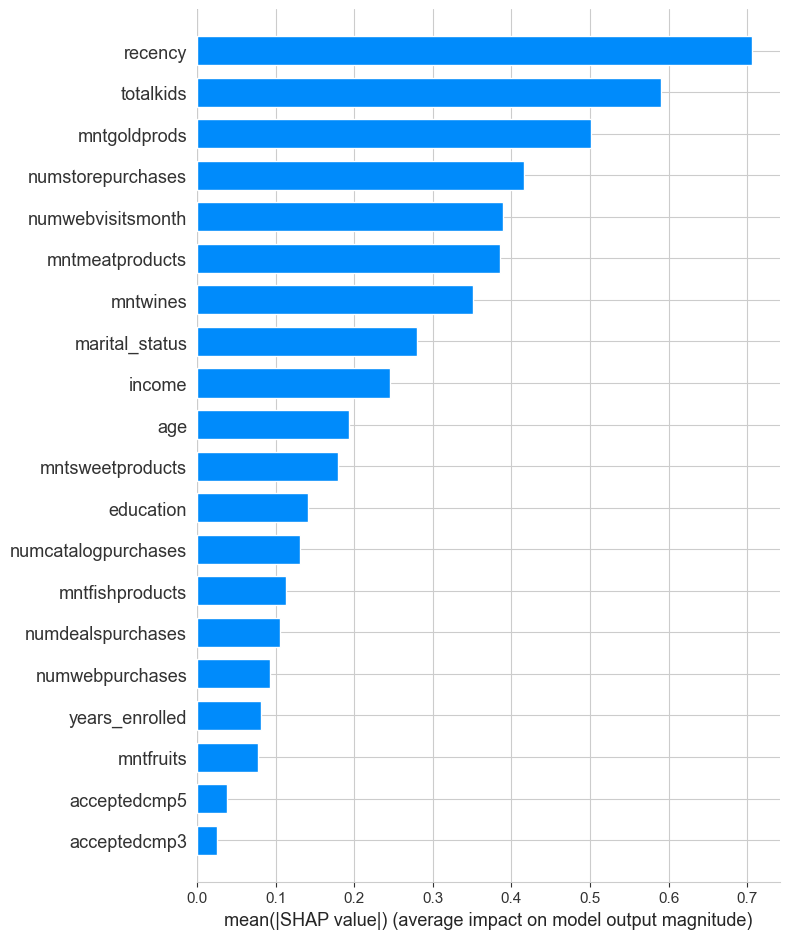

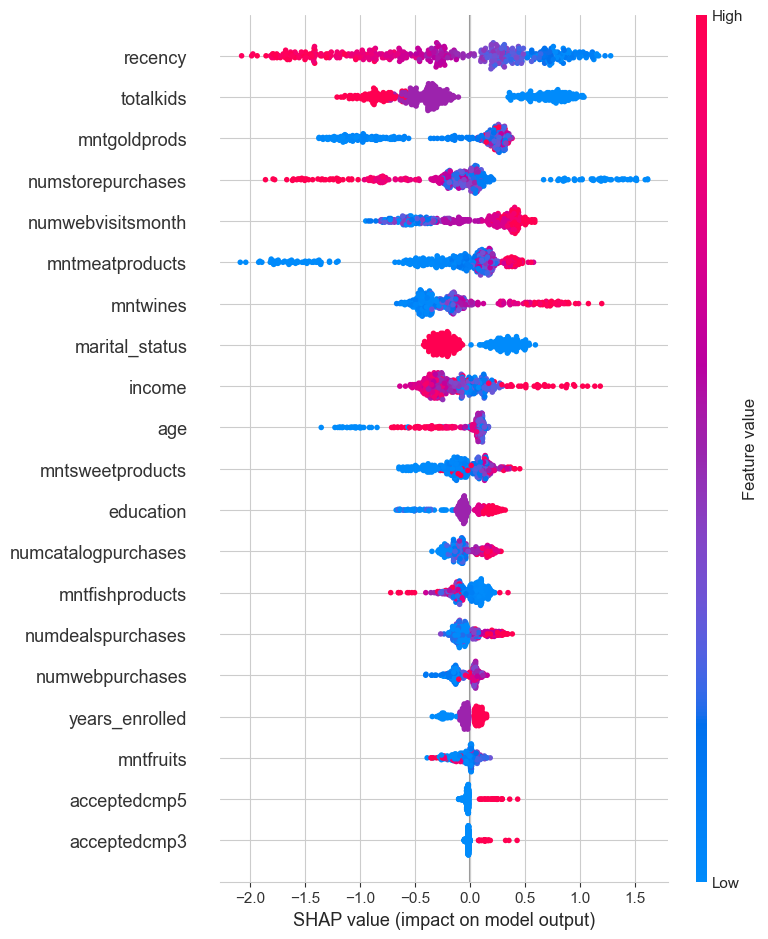

In [709]:
#Plotting Shap value graph for XGBoost


explainer_xgb = shap.TreeExplainer(model_xgb)

# Calculate SHAP values
shap_values_xgb = explainer_xgb.shap_values(X_test)

# displaying Global feature importance
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

# SHAP value distribution
shap.summary_plot(shap_values_xgb, X_test)


Features such as recency, totalkids, mntgoldprods and numstorepurchases have the highest SHAP impact, indicating they strongly influencing the models performance.

In [710]:

#Fetching top 3 features which has highest importance


importance_xgb = model_xgb.get_booster().get_score(importance_type='weight')

# Converting to DataFrame for sorting the values
importance_df_xgb = pd.DataFrame.from_dict(importance_xgb, orient='index', columns=['Importance'])
importance_df_xgb.index.name = 'Feature'
importance_df_xgb.reset_index(inplace=True)

top_3_features_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False).head(3)

print("Top 3 most important features in XGBoost:")
print(top_3_features_xgb)

Top 3 most important features in XGBoost:
              Feature  Importance
3             recency        77.0
2              income        64.0
13  numstorepurchases        57.0


We could see that features like recency, income and numstorepurchases are the highest contributers for the XGBoost model performance.

In [711]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {title}")
    plt.grid(False)
    plt.show()

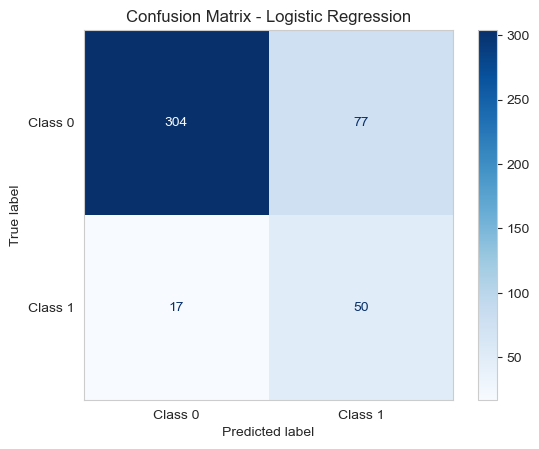

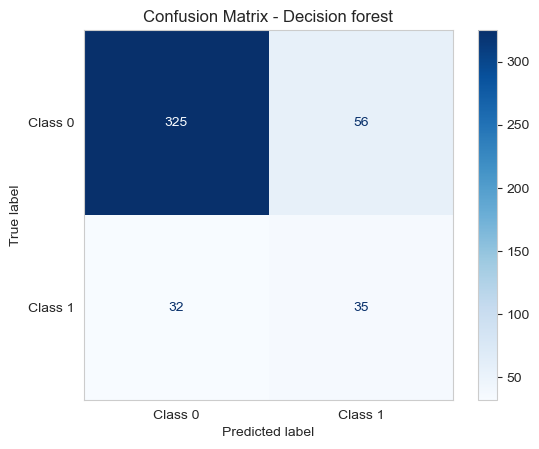

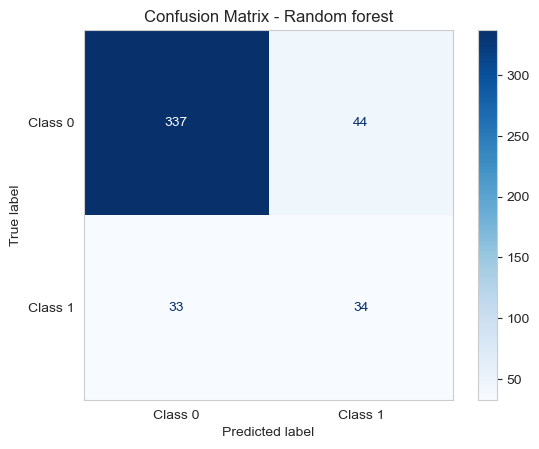

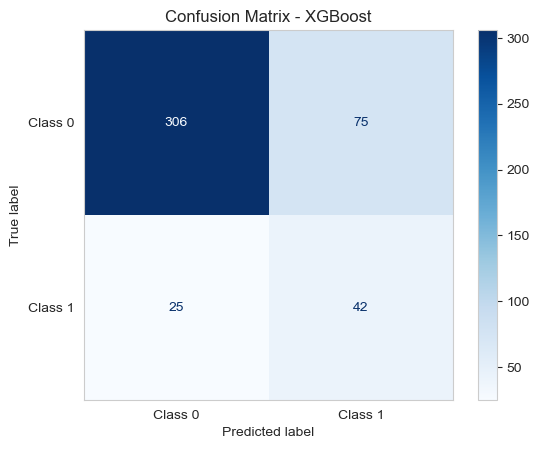

In [712]:
#Confusion matrix for the models

# Logistic Regression
plot_conf_matrix(y_test_lr, y_pred_lr, "Logistic Regression")

# Decision Tree
plot_conf_matrix(y_test, y_pred_dt, "Decision forest")

# Random forest
plot_conf_matrix(y_test, y_pred_rf, "Random forest")

# XGBoost
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost")


#### Logistic Regression

Model predicts Class 0 (negative class) fairly well but shows a higher number of false positives (77 instances). It also maintains a good balance by correctly identifying 50 true positives with relatively fewer false negatives (17).

#### Decision Tree

Decision Tree model correctly identifies 325 negative cases but struggles with positive class predictionsand  misclassifying 32 positives as negatives. It results in a higher number of false positives (56) which indicates slightly less reliability for sensitive predictions.

#### Random Forest

Random Forest demonstrates strong performance with the highest correct predictions for both Class 0 (337) and Class 1 (34). It has balanced confusion matrix which indicates good consistency across classes.

#### XGBoost

XGBoost correctly classified 306 instances of Class 0 and 42 instances of Class 1. It has made 75 false positives and 25 false negatives, indicating moderate misclassification but better balance between precision and recall compared to some other models.

In [713]:

# Creating a table to analyse all models metrics
performance_summary = {
    "Logistic Regression": {
        "Accuracy": accuracy_lr,
        "Precision": precision_lr,
        "Recall": recall_lr,
        "F1-Score": f1_lr,
        "AUC": roc_auc_lr
    },
    "Decision Tree": {
        "Accuracy": accuracy_dt,
        "Precision": precision_dt,
        "Recall": recall_dt,
        "F1-Score": f1_dt,
        "AUC": roc_auc_dt
    },
    "Random Forest": {
        "Accuracy": accuracy_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F1-Score": f1_rf,
        "AUC": roc_auc_rf
    },
    "XGBoost": {
        "Accuracy": accuracy_xgb,
        "Precision": precision_xgb,
        "Recall": recall_xgb,
        "F1-Score": f1_xgb,
        "AUC": roc_auc_xgb
    }
}


performance_df = pd.DataFrame(performance_summary).T  # transpose for model rows


performance_df = performance_df.round(4)


print("\nModel Performance Comparison:")
print(performance_df)



Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score     AUC
Logistic Regression    0.7902     0.8643  0.7902    0.8137  0.8897
Decision Tree          0.8036     0.8317  0.8036    0.8153  0.6998
Random Forest          0.8281     0.8398  0.8281    0.8334  0.8151
XGBoost                0.7768     0.8399  0.7768    0.7993  0.8220


Below are the highlights post analysing the models performance metrics 

1) Logistic Regression showed the highest AUC (0.8897) and precision (0.8643) making it effective for identifying true positives in imbalanced datasets.

2) Random Forest delivered the best balance in F1-Score (0.8334) and accuracy (0.8281) which indicates good overall performance.

3) Decision Tree performed moderately with F1-score (0.8153)) but had the lowest AUC (0.6998), signaling weaker separability.

4) XGBoost had competitive precision (0.8399) but slightly lower recall and F1-Score, indicating more room for tuning.

### Cross validation

1) Cross-validation helps us to evaluate how well a model generalizes to unseen data, providing a more reliable estimate of its real-world performance.

2) It reduces the risk of overfitting by validating the model on multiple subsets of the data, ensuring performance consistency across different data splits.

In [ ]:
#F1 Score compariosn for logistic regression using cross validation
models_cv_lr = {
    'Logistic regression': log_reg
}

# Stratified 5-Fold CV
cv_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_lr = []

for name, model in models_cv_lr.items():
    f1_lr_cv = cross_val_score(model, X_train_lr_rs, y_train_lr_rs, cv=cv_lr, scoring='f1_weighted')
    cv_results_lr.append({
        'Model': name,
        'Mean F1 Score': np.mean(f1_lr_cv),
        'Std F1 Score': np.std(f1_lr_cv)
    })

# Convert to DataFrame
cv_df_lr = pd.DataFrame(cv_results_lr).sort_values(by='Mean F1 Score', ascending=False)

# Print the comparison table
print("\nF1 Score compariosn for logistic regression (5-Fold CV):")
print(cv_df_lr.round(4))



F1 Score compariosn for logistic regression (5-Fold CV):
                 Model  Mean F1 Score  Std F1 Score
0  Logistic regression         0.8138        0.0133


1) Logistic Regression achieved a Mean F1 Score of 0.8138, indicating moderate predictive performance across folds.

2) With a standard deviation of 0.0133, its performance is relatively stable but lags behind ensemble methods like Random Forest in both accuracy and robustness.

In [ ]:
#F1 Score compariosn for Decision Tree, Random Forest and XGBoost  using cross validation
models = {
    'Decision Tree': model_dt,
    'Random Forest': model_rf,
    'XGBoost': model_xgb
}

# Stratified 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():
    f1 = cross_val_score(model, X_train_rs, y_train_rs, cv=cv, scoring='f1_weighted')
    cv_results.append({
        'Model': name,
        'Mean F1 Score': np.mean(f1),
        'Std F1 Score': np.std(f1)
    })

# Convert to DataFrame
cv_df = pd.DataFrame(cv_results).sort_values(by='Mean F1 Score', ascending=False)

# Print the comparison table
print("\nF1 Score Comparison (5-Fold CV):")
print(cv_df.round(4))



F1 Score Comparison (5-Fold CV):
           Model  Mean F1 Score  Std F1 Score
1  Random Forest         0.9219        0.0109
2        XGBoost         0.8743        0.0139
0  Decision Tree         0.8484        0.0057


1) Random Forest achieved the highest mean F1 Score (0.9219) with relatively low variance (Std: 0.0109), indicating both strong and consistent performance across folds.

2) XGBoost showed good performance with mean F1 Score (0.8743), it has slightly higher standard deviation (0.0139) which suggests more variability and Decision Tree underperformed comparatively with the lowest F1 score (0.8484).

## Hyper parameter tuning

Hyperparameter tuning optimizes model performance by finding the best combination of parameters that minimize error and maximize predictive accuracy. It also helps prevent to overfitting or underfitting, ensuring the model generalizes well to unseen data across different folds and datasets.

## Logistic regression model with hyperparameter tuning

In [ ]:
# Performing Hyperparameter tuning using Grid Search for Logistic Regression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    lr_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train_lr_rs, y_train_lr_rs)

print(lr_grid.best_params_)

{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


Logistic Regression with hyper parameter tuning Performance metrics
Accuracy : 0.8013
Precision: 0.8700
Recall   : 0.8013
F1 Score : 0.8230
AUC Score: 0.8917


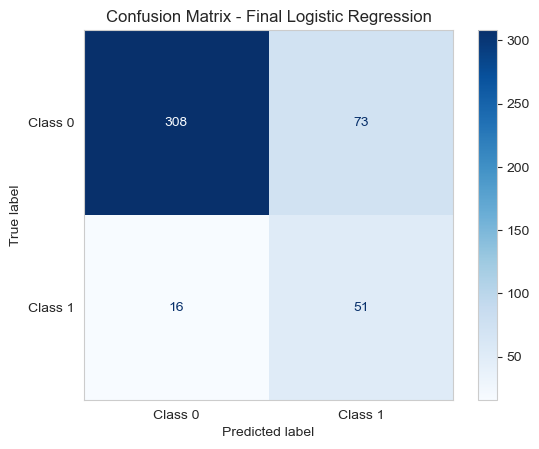

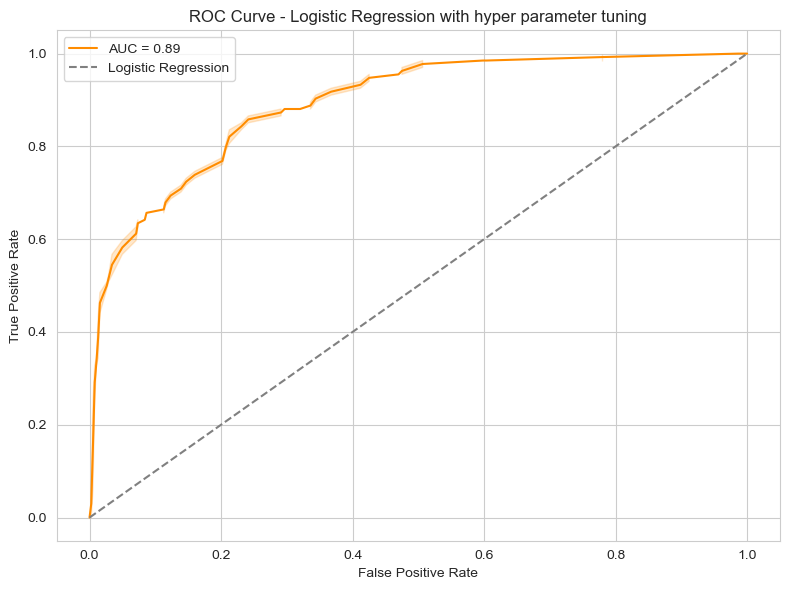

In [717]:
# Training Logistic Regression model with hyper parameter tuning
mod_lr_hp = LogisticRegression(C=10, penalty='l2', solver='liblinear', class_weight='balanced', max_iter=1000)
mod_lr_hp.fit(X_train_lr_rs, y_train_lr_rs)

# Predicting the target variables
y_pred_lr_hp = mod_lr_hp.predict(X_test_lr)
y_prob_lr_hp = mod_lr_hp.predict_proba(X_test_lr)[:, 1]

# Calculating the performance metrics 
accuracy_lr_hp = accuracy_score(y_test_lr, y_pred_lr_hp)
precision_lr_hp = precision_score(y_test_lr, y_pred_lr_hp, zero_division=1, average='weighted')
recall_lr_hp = recall_score(y_test_lr, y_pred_lr_hp, average='weighted')
f1_lr_hp = f1_score(y_test_lr, y_pred_lr_hp, average='weighted')
auc_lr_hp = roc_auc_score(y_test_lr, y_prob_lr_hp)


print("Logistic Regression with hyper parameter tuning Performance metrics")
print(f"Accuracy : {accuracy_lr_hp:.4f}")
print(f"Precision: {precision_lr_hp:.4f}")
print(f"Recall   : {recall_lr_hp:.4f}")
print(f"F1 Score : {f1_lr_hp:.4f}")
print(f"AUC Score: {auc_lr_hp:.4f}")

# Plotting Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test_lr, y_pred_lr_hp, display_labels=['Class 0', 'Class 1'], cmap='Blues')
plt.title("Confusion Matrix - Final Logistic Regression")
plt.grid(False)
plt.show()

# Plotting ROC AUC Curve
fpr_lr_hp, tpr_lr_hp, _ = roc_curve(y_test_lr, y_prob_lr_hp)
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_lr_hp, y=tpr_lr_hp, label=f"AUC = {auc_lr_hp:.2f}", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Logistic Regression')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression with hyper parameter tuning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Gettting the top 3 most influential features

feature_names_lr_hp = X_train_lr.columns

# Fetching the coefficients
coefficients_lr_hp = mod_lr_hp.coef_[0]

# Creating a DataFrame to perform sorting of the features
coef_df_lr_hp = pd.DataFrame({
    'Feature': feature_names_lr_hp,
    'Coefficient': coefficients_lr_hp,
    'Abs_Coefficient': np.abs(coefficients_lr_hp)
})

# Fetching top 3 features coefficients
top_features_lr_hp = coef_df_lr_hp.sort_values(by='Abs_Coefficient', ascending=False).head(3)

print("Top 3 most influential features (by absolute coefficient):")
print(top_features_lr_hp[['Feature', 'Coefficient']])


Top 3 most influential features (by absolute coefficient):
                Feature  Coefficient
4       mntmeatproducts     4.776021
12    numwebvisitsmonth     4.507929
10  numcatalogpurchases     4.248015


We could see that features like mntmeatproducts, numwebvisitsmonth and numcatalogpurchases are the highest contributers for the logistic model performance with hyper parameter tuning.

## Decision Tree model with hyperparameter tuning

In [ ]:
# Performing Hyperparameter tuning using Grid Search for Logistic Regression
dt_param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train_rs, y_train_rs)

# Displaying best parameters
print("Best hyperparameters for Decision Tree:")
print(dt_grid.best_params_)

Best hyperparameters for Decision Tree:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


Decision Tree with Hyperparameter Tuning Performance metrics
Accuracy : 0.8103
Precision: 0.8298
Recall   : 0.8103
F1 Score : 0.8188
AUC Score: 0.6972


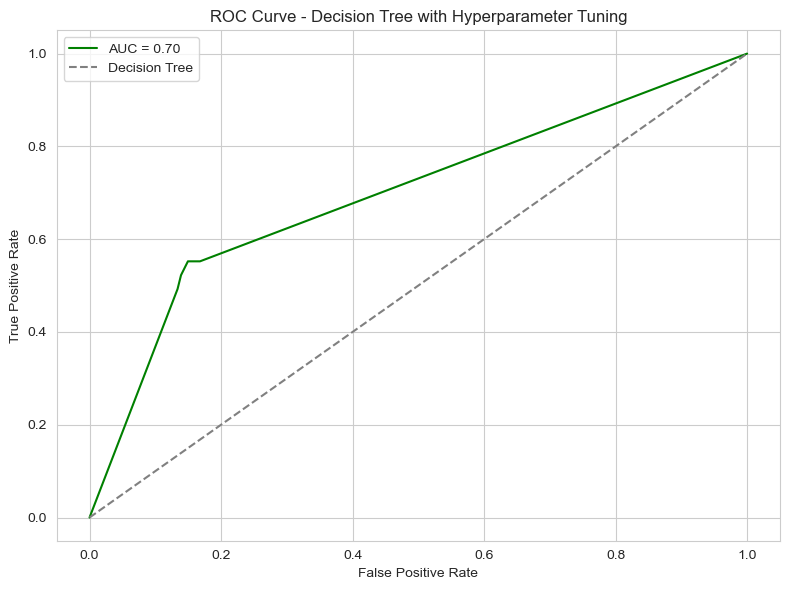

In [ ]:
# Training Logistic Regression model with hyper parameter tuning

model_dt_hp = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=34
)

# Train the model
model_dt_hp.fit(X_train_rs, y_train_rs)

# Predicting the target variables
y_pred_dt_hp = model_dt_hp.predict(X_test)
y_prob_dt_hp = model_dt_hp.predict_proba(X_test)[:, 1]

# Calculating the performance metrics 
accuracy_dt_hp = accuracy_score(y_test, y_pred_dt_hp)
precision_dt_hp = precision_score(y_test, y_pred_dt_hp, average='weighted')
recall_dt_hp = recall_score(y_test, y_pred_dt_hp, average='weighted')
f1_dt_hp = f1_score(y_test, y_pred_dt_hp, average='weighted')
auc_dt_hp = roc_auc_score(y_test, y_prob_dt_hp)


print("Decision Tree with Hyperparameter Tuning Performance metrics")
print(f"Accuracy : {accuracy_dt_hp:.4f}")
print(f"Precision: {precision_dt_hp:.4f}")
print(f"Recall   : {recall_dt_hp:.4f}")
print(f"F1 Score : {f1_dt_hp:.4f}")
print(f"AUC Score: {auc_dt_hp:.4f}")

# Plotting ROC AUC Curve
fpr_dt_hp, tpr_dt_hp, _ = roc_curve(y_test, y_prob_dt_hp)
plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_dt_hp, y=tpr_dt_hp, label=f"AUC = {auc_dt_hp:.2f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Decision Tree')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree with Hyperparameter Tuning")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1) Model achieves Accuracy (0.8103), Precision (0.8298) and F1 Score (0.8188), indicating decent overall classification performance.

2) AUC Score (0.6972) suggests weaker ability to differentiate between classes, making it less ideal for imbalanced data scenarios.

3) ROC curve shows moderate classification performance with an AUC of 0.70, suggesting the model can distinguish between classes slightly better than random guessing.

In [721]:
# Getting top 3 important features for Decision Tree model
feature_names_hp = X_train.columns

# Extract feature importances
importances_dt_hp = model_dt_hp.feature_importances_

# Create a DataFrame to sort by importance
importance_df_dt_hp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_dt_hp
})

# Sort and get top 3 features
top_3_features_dt_hp = importance_df_dt_hp.sort_values(by='Importance', ascending=False).head(3)

print("Top 3 most important features in Decision Tree:")
print(top_3_features_dt_hp)


Top 3 most important features in Decision Tree:
              Feature  Importance
3             recency    0.128654
22          totalkids    0.104400
14  numwebvisitsmonth    0.093678


We could see that features like recency, totalkids and numwebvisitsmonth are the highest contributers for the Decision Tree model performance with hyperparameter tuning.

## Random Forest model with hyperparameter tuning

In [ ]:
# Performing Hyperparameter tuning using Grid Search for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],                
    'max_depth': [None, 10, 15],               
    'min_samples_split': [2, 5],               
    'min_samples_leaf': [1, 2],                
    'max_features': ['sqrt', 'log2'],          
    'criterion': ['gini', 'entropy']           
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_rs, y_train_rs)

# Displaying best parameters
print("Best hyperparameters for Random Forest:")
print(rf_grid.best_params_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best hyperparameters for Random Forest:
{'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


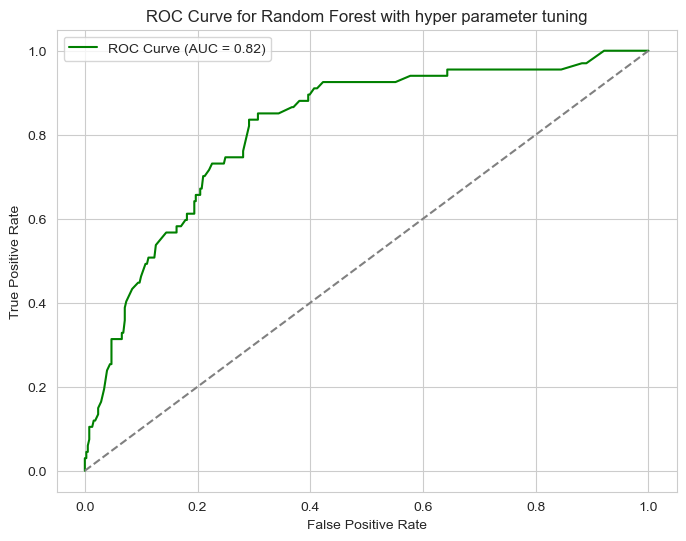


Random Forest Model Performance with hyper parameter tuning:
Accuracy : 0.8281
Precision: 0.8398
Recall   : 0.8281
F1 Score : 0.8334
AUC Score: 0.8151


In [ ]:

# Initialize Random Forest with the parameters obtained from GridSearchCV
model_rf_hp = RandomForestClassifier(
    n_estimators=100,              
    max_depth=None,                
    min_samples_split=2,           
    min_samples_leaf=1,            
    max_features='sqrt',           
    criterion='gini',              
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training the model
model_rf_hp.fit(X_train_rs, y_train_rs)

# Predicting the target values
y_pred_rf_hp = model_rf_hp.predict(X_test)
y_prob_rf_hp = model_rf_hp.predict_proba(X_test)[:, 1]

# Calculate performance metrics
accuracy_rf_hp = accuracy_score(y_test, y_pred_rf_hp)
precision_rf_hp = precision_score(y_test, y_pred_rf_hp, average='weighted')
recall_rf_hp = recall_score(y_test, y_pred_rf_hp, average='weighted')
f1_rf_hp = f1_score(y_test, y_pred_rf_hp, average='weighted')

# ROC Curve and AUC
fpr_rf_hp, tpr_rf_hp, _ = roc_curve(y_test, y_prob_rf_hp)
roc_auc_rf_hp = auc(fpr_rf_hp, tpr_rf_hp)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_hp, tpr_rf_hp, color='green', label=f'ROC Curve (AUC = {roc_auc_rf_hp:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forest with hyper parameter tuning')
plt.legend()
plt.grid(True)
plt.show()

# Displaying metrics
print("\nRandom Forest Model Performance with hyper parameter tuning:")
print(f"Accuracy : {accuracy_rf_hp:.4f}")
print(f"Precision: {precision_rf_hp:.4f}")
print(f"Recall   : {recall_rf_hp:.4f}")
print(f"F1 Score : {f1_rf_hp:.4f}")
print(f"AUC Score: {roc_auc_rf_hp:.4f}")


1) Model shows strong performance with Accuracy (0.8281), Precision (0.8398) and Recall = 82.81%, showing it's well-balanced in predicting both classes.

2) F1 Score (0.8334) and AUC Score (0.8151) indicate good predictive power and class discrimination.

In [724]:

#Fetching top 3 important features
importances_rf_hp = model_rf_hp.feature_importances_

#Creating a DataFrame for sorting the values
importance_df_rf_hp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_rf_hp
})

top_3_features_rf_hp = importance_df_rf_hp.sort_values(by='Importance', ascending=False).head(3)

print("Top 3 most important features in Random Forest:")
print(top_3_features_rf_hp)


Top 3 most important features in Random Forest:
        Feature  Importance
3       recency    0.121361
2        income    0.092568
9  mntgoldprods    0.089958


We could see that features like income, recency and mntgoldprods are the highest contributers for the Random Fores model performance with hyper parameter tuning.

## XGBoost model with hyper parameter tuning 

In [725]:
# Count positive and negative classes
neg_count = (y_train_rs == 0).sum()
pos_count = (y_train_rs == 1).sum()

# Compute the ratio
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


scale_pos_weight: 1.00


In [ ]:
# Defining parameter grid
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'reg_lambda': [1, 5],
    'reg_alpha': [0, 1]
}

# Initialize model with imbalance handling
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

# Grid Search for XGBoost
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit the model
xgb_grid.fit(X_train_rs, y_train_rs)

# Displaying hyperparameters
print("Best hyperparameters for XGBoost (with class imbalance):")
print(xgb_grid.best_params_)


Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Best hyperparameters for XGBoost (with class imbalance):
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}


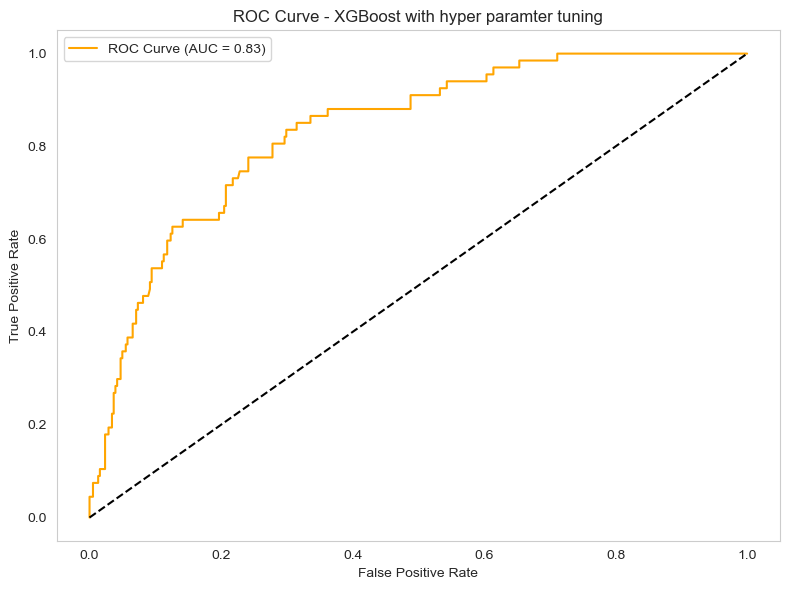


XGBoost Model Performance with hyper paramter tuning:
Accuracy : 0.8482
Precision: 0.8539
Recall   : 0.8482
F1 Score : 0.8509
AUC Score: 0.8335


In [ ]:
# Initialize XGBoost with the parameters obtained from GridSearchCV
model_xgb_hp = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=1025,
    n_jobs=-1
)

# Training the model
model_xgb_hp.fit(X_train_rs, y_train_rs)

# Predicting the target values
y_pred_xgb_hp = model_xgb_hp.predict(X_test)
y_prob_xgb_hp = model_xgb_hp.predict_proba(X_test)[:, 1]

# Calculating the performance metrics
accuracy_xgb_hp = accuracy_score(y_test, y_pred_xgb_hp)
precision_xgb_hp = precision_score(y_test, y_pred_xgb_hp, average='weighted')
recall_xgb_hp = recall_score(y_test, y_pred_xgb_hp, average='weighted')
f1_xgb_hp = f1_score(y_test, y_pred_xgb_hp, average='weighted')
fpr_xgb_hp, tpr_xgb_hp, _ = roc_curve(y_test, y_prob_xgb_hp)
roc_auc_xgb_hp = auc(fpr_xgb_hp, tpr_xgb_hp)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb_hp, tpr_xgb_hp, label=f'ROC Curve (AUC = {roc_auc_xgb_hp:.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost with hyper paramter tuning')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Displaying metrics
print("\nXGBoost Model Performance with hyper paramter tuning:")
print(f"Accuracy : {accuracy_xgb_hp:.4f}")
print(f"Precision: {precision_xgb_hp:.4f}")
print(f"Recall   : {recall_xgb_hp:.4f}")
print(f"F1 Score : {f1_xgb_hp:.4f}")
print(f"AUC Score: {roc_auc_xgb_hp:.4f}")

1) The model achieved strong overall performance with Accuracy (0.8482), Precision (0.8539) and Recall (0.8482) indicating a well-balanced classifier.

2) A high F1 Score of (0.8509) and AUC Score of (0.8335) further confirm the models excellent predictive power and ability to distinguish between classes effectively.

3) The ROC curve shows a strong separation between classes with an AUC of 0.83, indicating that the model is highly effective at distinguishing between positive and negative responses.

4) The curve rises sharply toward the top-left corner demonstrating a high true positive rate and low false positive rate which reflects strong classification performance.



In [ ]:

#Fetching top 3 features which has highest importance
importance_xgb_hp = model_xgb_hp.get_booster().get_score(importance_type='weight')

# Converting to DataFrame for sorting the values
importance_df_xgb_hp = pd.DataFrame.from_dict(importance_xgb_hp, orient='index', columns=['Importance'])
importance_df_xgb_hp.index.name = 'Feature'
importance_df_xgb_hp.reset_index(inplace=True)

top_3_features_xgb_hp = importance_df_xgb_hp.sort_values(by='Importance', ascending=False).head(3)

print("Top 3 most important features in XGBoost:")
print(top_3_features_xgb_hp)

Top 3 most important features in XGBoost:
        Feature  Importance
2        income       899.0
3       recency       649.0
9  mntgoldprods       603.0


We could see that features like income, recency and mntgoldprods are the highest contributers for the XGBoost model performance with hyper parameter tuning.

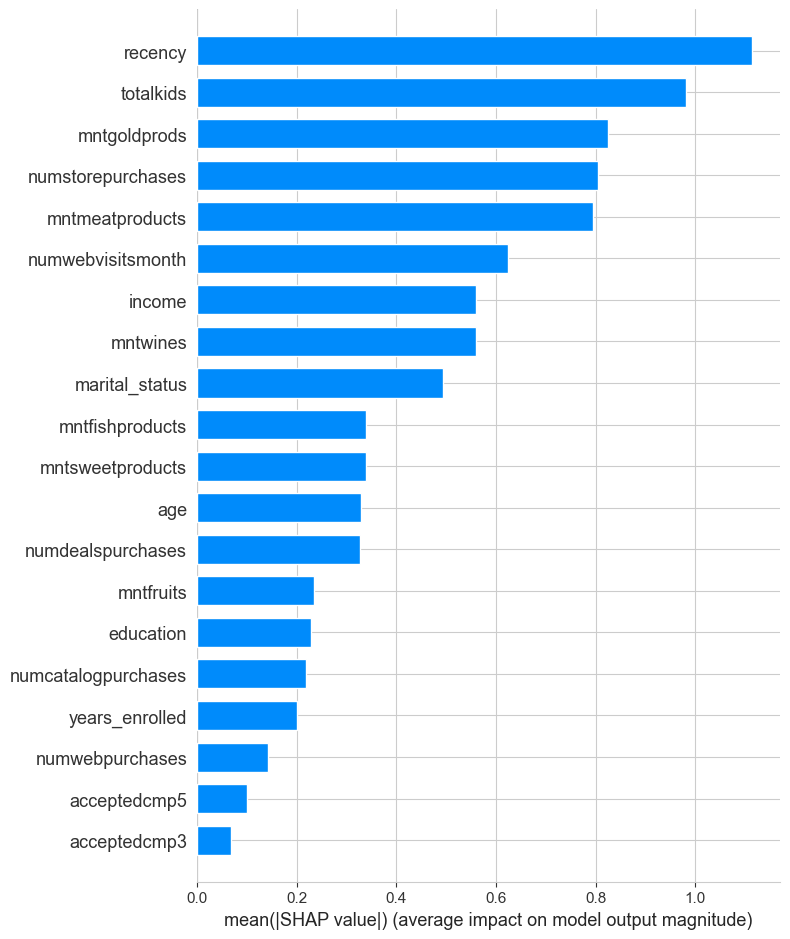

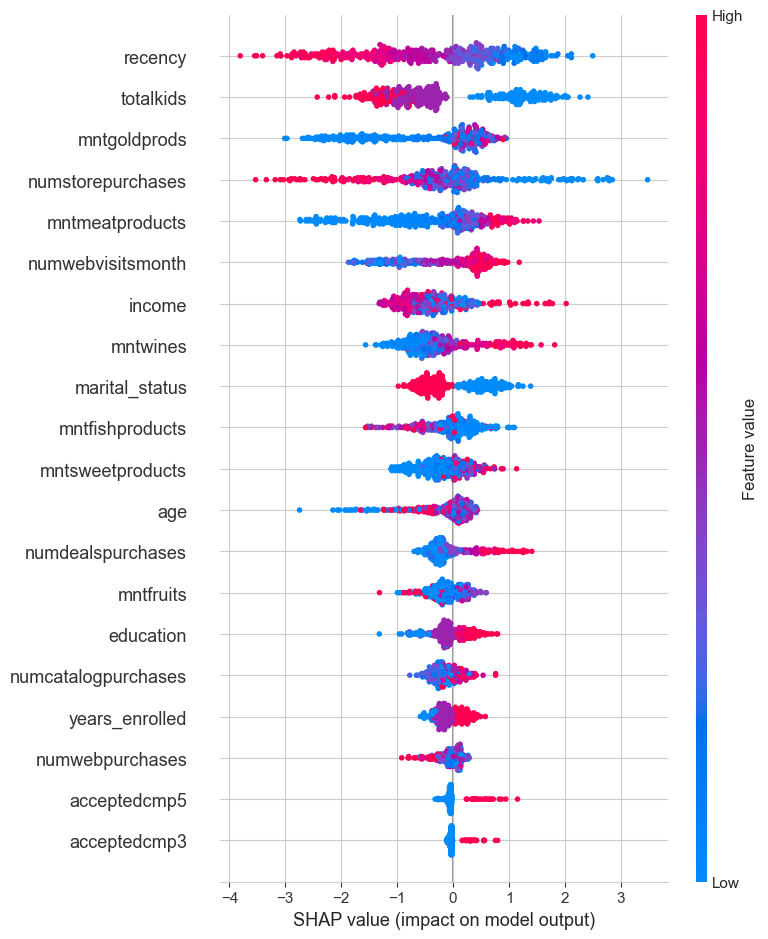

In [ ]:
#Plotting Shap value graph for XGBoost
explainer_xgb_hp = shap.TreeExplainer(model_xgb_hp)

# Calculate SHAP values
shap_values_xgb_hp = explainer_xgb_hp.shap_values(X_test)

# displaying Global feature importance
shap.summary_plot(shap_values_xgb_hp, X_test, plot_type="bar")

# SHAP value distribution
shap.summary_plot(shap_values_xgb_hp, X_test)


1) Top influcencing features like recency, totalkids, and mntgoldprods have the greatest impact on the model's prediction with higher values displayed in color red, generally decreasing the likelihood of a positive response.

2) Features such as income, numstorepurchases, and numwebvisitsmonth also contribute significantly, indicating that both customer demographics and purchase behaviors drive campaign response predictions.

### Confusion matrix for the models with Hyper parameter tuning

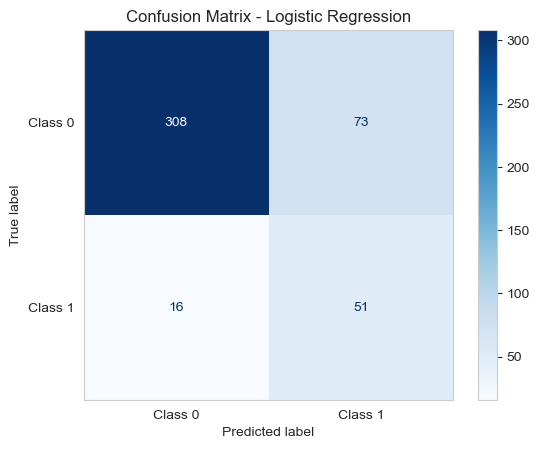

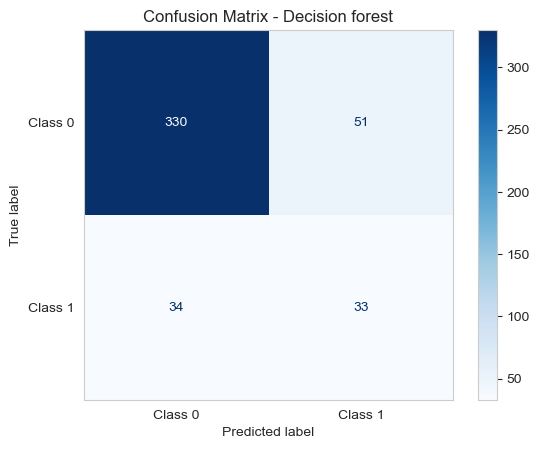

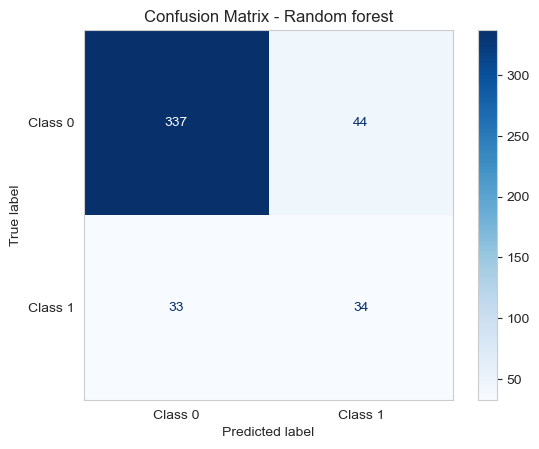

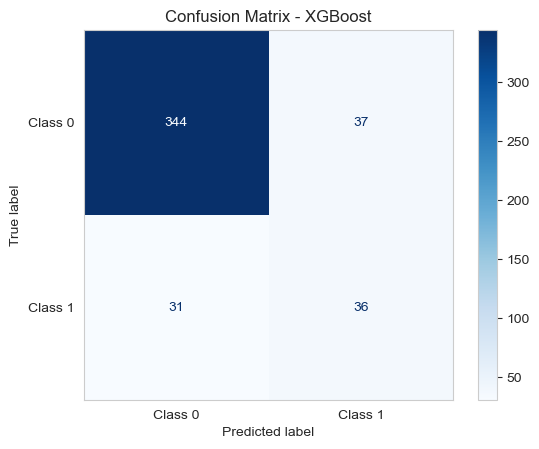

In [730]:
#Confusion matrix for the models with Hyper parameter tuning 

# Logistic Regression
plot_conf_matrix(y_test_lr, y_pred_lr_hp, "Logistic Regression")

# Decision Tree
plot_conf_matrix(y_test, y_pred_dt_hp, "Decision forest")

# Random forest
plot_conf_matrix(y_test, y_pred_rf_hp, "Random forest")

# XGBoost
plot_conf_matrix(y_test, y_pred_xgb_hp, "XGBoost")


##### Logistic regression:

1) Correctly predicted 308 negatives and 51 positives with 73 false positives and 16 false negatives.

2) From the above data we could see that it has the lowest false negative count which means it is strong at detecting actual positive cases (Class 1).

##### Decision Tree:

1) Predicted 330 negatives and 33 positives, but misclassified 34 actual positives as negatives.

2) From the above data we could see that it has a higher false negative rate which may risk missing actual responders.

##### Random Forest:

1) Improved balance with 337 true negatives and 34 true positives, and reduced false predictions.

2) It is better than Decision Tree in minimizing both false positives and false negatives, leading to better overall reliability.

##### XGBoost:

1) Correctly identified 344 true negatives and 36 true positives and has the lowest total misclassifications (68).

2)  We could observe fewer false predictions in both classes (class 0 and class 1)

##### Creating table containing all model performance metrics to analyze

In [ ]:

# Creating a table to analyse  models metrics with hyper parameter tuning
performance_summary_hp = {
    "Logistic Regression with HP": {
        "Accuracy": accuracy_lr_hp,
        "Precision": precision_lr_hp,
        "Recall": recall_lr_hp,
        "F1-Score": f1_lr_hp,
        "AUC": auc_lr_hp
    },
    "Decision Tree with HP": {
        "Accuracy": accuracy_dt_hp,
        "Precision": precision_dt_hp,
        "Recall": recall_dt_hp,
        "F1-Score": f1_dt_hp,
        "AUC": auc_dt_hp
    },
    "Random Forest with HP": {
        "Accuracy": accuracy_rf_hp,
        "Precision": precision_rf_hp,
        "Recall": recall_rf_hp,
        "F1-Score": f1_rf_hp,
        "AUC": roc_auc_rf_hp
    },
    "XGBoost with HP": {
        "Accuracy": accuracy_xgb_hp,
        "Precision": precision_xgb_hp,
        "Recall": recall_xgb_hp,
        "F1-Score": f1_xgb_hp,
        "AUC": roc_auc_xgb_hp
    }
}


performance_df_hp = pd.DataFrame(performance_summary_hp).T 


performance_df_hp = performance_df_hp.round(4)


print("\nModel Performance Comparison with Hyper parameter tuning:")
print(performance_df_hp)



Model Performance Comparison with Hyper parameter tuning:
                             Accuracy  Precision  Recall  F1-Score     AUC
Logistic Regression with HP    0.8013     0.8700  0.8013    0.8230  0.8917
Decision Tree with HP          0.8103     0.8298  0.8103    0.8188  0.6972
Random Forest with HP          0.8281     0.8398  0.8281    0.8334  0.8151
XGBoost with HP                0.8482     0.8539  0.8482    0.8509  0.8335


1) Logistic Regression with HP achieves an excellent AUC (0.8917) and strong precision, making it reliable for class separation.

2) Decision Tree with HP provides good accuracy but a relatively low AUC (0.6972), indicating limited predictive power.

3) Random Forest with HP provides a well-balanced performance across all metrics, making it a robust and consistent model.

4) XGBoost with HP outperforms all models with the highest F1-score (0.8509) and accuracy (0.8482), ideal for precise and scalable predictions.

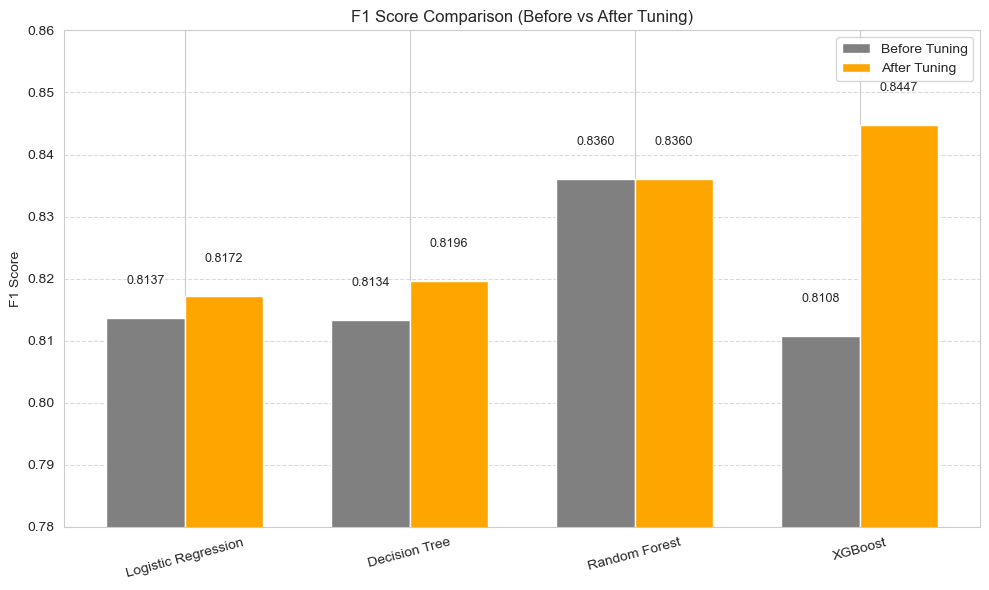

In [ ]:

# Comparing F1 scores between the models before and after hyper parameter tuning
labels = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
f1_before = [0.8137, 0.8134, 0.8360, 0.8108]
f1_after = [0.8172, 0.8196, 0.8360, 0.8447]

x = range(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))


bars1 = plt.bar(x, f1_before, width=width, label='Before Tuning', color='gray')
bars2 = plt.bar([p + width for p in x], f1_after, width=width, label='After Tuning', color='orange')


for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontsize=9)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontsize=9)


plt.xticks([p + width / 2 for p in x], labels, rotation=15)
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison (Before vs After Tuning)')
plt.legend()
plt.ylim(0.78, 0.86)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


1) XGBoost showed the most significant improvement after hyperparameter tuning, with its F1 score increasing from 0.8108 to 0.8447, highlighting the impact of tuning on boosting.models.

2) Other models like Logistic Regression and Decision Tree saw only slight gains, while Random Forest's performance remained stable.

Cross-Validation for assessing performance consistency of models with hyper parameter tuning.

In [ ]:
#F1 Score validation for logistic regression with hyper parameter tuning using cross validation
models_cv_lr_hp = {
    'Logistic regression': mod_lr_hp
}

# Stratified 5-Fold CV
cv_lr_hp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_lr_hp = []

for name, model in models_cv_lr_hp.items():
    f1_lr_cv_hp = cross_val_score(model, X_train_lr_rs, y_train_lr_rs, cv=cv_lr, scoring='f1_weighted')
    cv_results_lr_hp.append({
        'Model': name,
        'Mean F1 Score': np.mean(f1_lr_cv_hp),
        'Std F1 Score': np.std(f1_lr_cv_hp)
    })


cv_df_lr_hp = pd.DataFrame(cv_results_lr_hp).sort_values(by='Mean F1 Score', ascending=False)

# Displaying the comparison table
print("\nF1 Score compariosn for logistic regression with hyper parameter tuning (5-Fold CV):")
print(cv_df_lr_hp.round(4))



F1 Score compariosn for logistic regression with hyper parameter tuning (5-Fold CV):
                 Model  Mean F1 Score  Std F1 Score
0  Logistic regression          0.821        0.0152


1) Logistic Regression with hyperparameter tuning achieved a mean F1 score of 0.821, indicating moderate classification performance.

2) Also, its higher standard deviation (0.0152) suggests greater variability across folds, making it less consistent.


In [ ]:
#F1 Score validation for Decision Tree, Random Forest, XGBoost with hyper parameter tuning using cross validation

models_hp = {
    'Decision Tree with HP': model_dt_hp,
    'Random Forest with HP': model_rf_hp,
    'XGBoost with HP': model_xgb_hp
}

# Stratified 5-Fold CV
cv_hp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


cv_results_hp = []

for name, model in models.items():
    f1_hp = cross_val_score(model, X_train_rs, y_train_rs, cv=cv, scoring='f1_weighted')
    cv_results_hp.append({
        'Model': name,
        'Mean F1 Score': np.mean(f1_hp),
        'Std F1 Score': np.std(f1_hp)
    })


cv_df_hp = pd.DataFrame(cv_results_hp).sort_values(by='Mean F1 Score', ascending=False)

# Print the comparison table
print("\nF1 Score Comparison between models with hyper parameter tuning (5-Fold CV):")
print(cv_df_hp.round(4))



F1 Score Comparison between models with hyper parameter tuning (5-Fold CV):
           Model  Mean F1 Score  Std F1 Score
1  Random Forest         0.9219        0.0109
2        XGBoost         0.8743        0.0139
0  Decision Tree         0.8484        0.0057


1) Random Forest achieved the highest mean F1 score (0.9219), indicating strong and consistent performance across all folds. 

2) Decision Tree showed the lowest variability (Std F1 = 0.0057) and lower mean F1 (0.8484) suggests weaker overall predictive power.

3) XGBoost demonstrated a solid mean F1 score (0.8743) but its higher standard deviation (0.0139) indicates that its performance is less stable across different folds, making it slightly less consistent

### Comparing and analyzing the models performance 

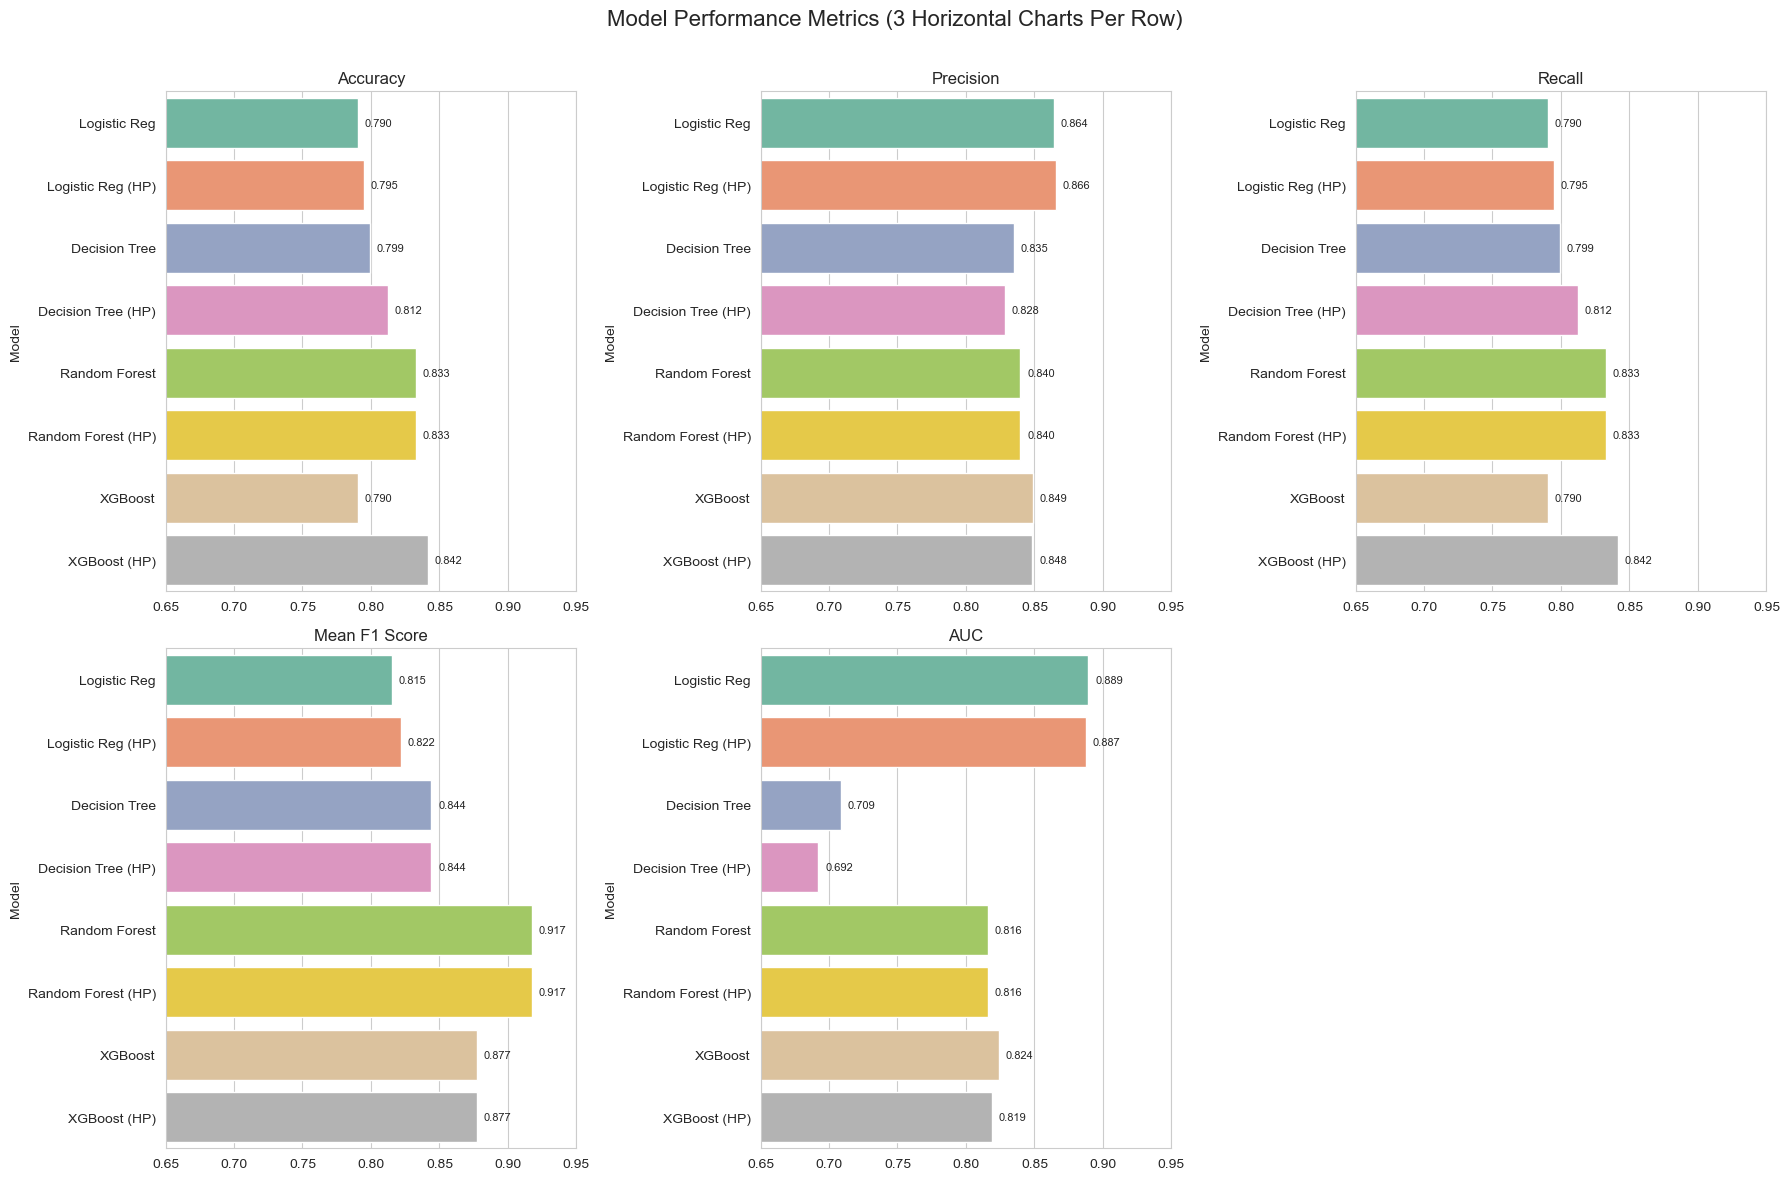

In [ ]:
# Visualizing the performance metrics across all models before and after hyper parameter tuning
data = {
    'Model': [
        'Logistic Reg', 'Logistic Reg (HP)', 
        'Decision Tree', 'Decision Tree (HP)', 
        'Random Forest', 'Random Forest (HP)', 
        'XGBoost', 'XGBoost (HP)'
    ],
    'Accuracy': [0.7902, 0.7946, 0.7991, 0.8125, 0.8326, 0.8326, 0.7902, 0.8415],
    'Precision': [0.8643, 0.8655, 0.8348, 0.8284, 0.8398, 0.8398, 0.8489, 0.8484],
    'Recall': [0.7902, 0.7946, 0.7991, 0.8125, 0.8326, 0.8326, 0.7902, 0.8415],
    'Mean F1 Score': [0.8154, 0.8216, 0.8441, 0.8441, 0.9173, 0.9173, 0.8772, 0.8772],
    'AUC': [0.8894, 0.8873, 0.7088, 0.6922, 0.8160, 0.8160, 0.8239, 0.8187]
}

# Creating DataFrame to load the values
df = pd.DataFrame(data)


sns.set_style("whitegrid")
metrics = ['Accuracy', 'Precision', 'Recall', 'Mean F1 Score', 'AUC']

# Create subplots with 3 charts per row
rows = (len(metrics) + 2) // 3
fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(18, 6 * rows))
axes = axes.flatten()

# Plotting each  performance metric
for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.barplot(ax=ax, y='Model', x=metric, data=df, palette='Set2')
    ax.set_title(metric, fontsize=12)
    ax.set_xlim(0.65, 0.95)
    ax.set_xlabel('')
    ax.set_ylabel('Model')

    # Adding lables to graph
    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(width + 0.005, y, f'{width:.3f}', ha='left', va='center', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# formatting the layout
fig.suptitle("Model Performance Metrics (3 Horizontal Charts Per Row)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


1) XGBoost with hyperparameter tuning consistently achieved the highest scores in accuracy (0.842) and recall (0.842) making it the most balanced and robust model.

2) Logistic Regression stood out with the highest AUC (0.889) and strong precision (0.866) with hyper parameter tuning showing greater ability to rank predictions correctly.

3) Random Forest with and without hyperparameter tuning demonstrated the highest mean F1-score (0.917) indicating consistent performance across folds.

4) Decision Tree models with and without hyperparameter tuning has lower AUC values suggesting weaker classification capability compared to ensemble models

In [736]:
mean_f1_lr = round(cv_df_lr.loc[cv_df_lr['Model'] == 'Logistic regression', 'Mean F1 Score'].values[0], 4)
mean_f1_dt = cv_df.loc[cv_df['Model'] == 'Decision Tree', 'Mean F1 Score'].values[0].round(4)
mean_f1_rf = cv_df.loc[cv_df['Model'] == 'Random Forest', 'Mean F1 Score'].values[0].round(4)
mean_f1_xgb = cv_df.loc[cv_df['Model'] == 'XGBoost', 'Mean F1 Score'].values[0].round(4)
mean_f1_lr_hp = round(cv_df_lr_hp.loc[cv_df_lr_hp['Model'] == 'Logistic regression', 'Mean F1 Score'].values[0], 4)
mean_f1_dt_hp = cv_df_hp.loc[cv_df_hp['Model'] == 'Decision Tree', 'Mean F1 Score'].values[0].round(4)
mean_f1_rf_hp = cv_df_hp.loc[cv_df_hp['Model'] == 'Random Forest', 'Mean F1 Score'].values[0].round(4)
mean_f1_xgb_hp = cv_df_hp.loc[cv_df_hp['Model'] == 'XGBoost', 'Mean F1 Score'].values[0].round(4)




st_f1_lr = round(cv_df_lr.loc[cv_df_lr['Model'] == 'Logistic regression', 'Std F1 Score'].values[0], 4)
st_f1_dt = cv_df.loc[cv_df['Model'] == 'Decision Tree', 'Std F1 Score'].values[0].round(4)
st_f1_rf = cv_df.loc[cv_df['Model'] == 'Random Forest', 'Std F1 Score'].values[0].round(4)
st_f1_xgb = cv_df.loc[cv_df['Model'] == 'XGBoost', 'Std F1 Score'].values[0].round(4)
st_f1_lr_hp = round(cv_df_lr_hp.loc[cv_df_lr_hp['Model'] == 'Logistic regression', 'Std F1 Score'].values[0], 4)
st_f1_dt_hp = cv_df_hp.loc[cv_df_hp['Model'] == 'Decision Tree', 'Std F1 Score'].values[0].round(4)
st_f1_rf_hp = cv_df_hp.loc[cv_df_hp['Model'] == 'Random Forest', 'Std F1 Score'].values[0].round(4)
st_f1_xgb_hp = cv_df_hp.loc[cv_df_hp['Model'] == 'XGBoost', 'Std F1 Score'].values[0].round(4)

In [ ]:

# Model names
models = [
    "Logistic Regression", "Decision Tree", "Random Forest", "XGBoost",
    "Logistic Regression with HP", "Decision Tree with HP", 
    "Random Forest with HP", "XGBoost with HP"
]

# Variable references as strings
accuracy_vars = [
    accuracy_lr, accuracy_dt, accuracy_rf, accuracy_xgb,
    accuracy_lr_hp, accuracy_dt_hp, accuracy_rf_hp, accuracy_xgb_hp
]

precision_vars = [
    precision_lr, precision_dt, precision_rf, precision_xgb,
    precision_lr_hp, precision_dt_hp, precision_rf_hp, precision_xgb_hp
]

recall_vars = [
    recall_lr, recall_dt, recall_rf, recall_xgb,
    recall_lr_hp, recall_dt_hp, recall_rf_hp, recall_xgb_hp
]

f1_vars = [
    f1_lr, f1_dt, f1_rf, f1_xgb,
    f1_lr_hp, f1_dt_hp, f1_rf_hp, f1_xgb_hp
]

auc_vars = [
    roc_auc_lr, roc_auc_dt, roc_auc_rf, roc_auc_xgb,
    auc_lr_hp, auc_dt_hp, roc_auc_rf_hp, roc_auc_xgb_hp
]

mean_f1_vars = [
    mean_f1_lr, mean_f1_dt, mean_f1_rf, mean_f1_xgb,
    mean_f1_lr_hp, mean_f1_dt_hp, mean_f1_rf_hp, mean_f1_xgb_hp
]

std_f1_vars = [
    st_f1_lr, st_f1_dt, st_f1_rf, st_f1_xgb,
    st_f1_lr_hp, st_f1_dt_hp, st_f1_rf_hp, st_f1_xgb_hp
]


# Creating DataFrame
table_with_variable_names = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy_vars,
    "Precision": precision_vars,
    "Recall": recall_vars,
    "F1-Score": f1_vars,
    "AUC": auc_vars,
    "Mean F1 SCORE": mean_f1_vars,
    "STD F1 SCore": std_f1_vars
})


table_with_variable_names = table_with_variable_names.round(4)


# Display the results
from IPython.display import display
display(table_with_variable_names)



,Model,Accuracy,Precision,Recall,F1-Score,AUC,Mean F1 SCORE,STD F1 SCore
0,Logistic Regression,0.7902,0.8643,0.7902,0.8137,0.8897,0.8138,0.0133
1,Decision Tree,0.8036,0.8317,0.8036,0.8153,0.6998,0.8484,0.0057
2,Random Forest,0.8281,0.8398,0.8281,0.8334,0.8151,0.9219,0.0109
3,XGBoost,0.7768,0.8399,0.7768,0.7993,0.8220,0.8743,0.0139
4,Logistic Regression with HP,0.8013,0.8700,0.8013,0.8230,0.8917,0.8210,0.0152
5,Decision Tree with HP,0.8103,0.8298,0.8103,0.8188,0.6972,0.8484,0.0057
6,Random Forest with HP,0.8281,0.8398,0.8281,0.8334,0.8151,0.9219,0.0109
7,XGBoost with HP,0.8482,0.8539,0.8482,0.8509,0.8335,0.8743,0.0139


## Models performance comparision and highlights

Upon comparing the performance metrics of all models (with and without hyper parameter tuning) following key insights were obtained.

1) XGBoost with hyper parameter tuning achieved the highest overall performance with an F1-score of 0.8509, accuracy of 0.8482, and a strong AUC of 0.8335. This shows that the model has a strong balance between correctly identifying positive responses while minimizing false positives and false negatives.

2) Considering the base model Logistic regression with hyperparameter tuning also showed the highest AUC of 0.8917 and precision of 0.87, but its F1-score was lower (0.823) compared to XGBoost with hyperparameter tuning (0.8509) highlighting that it is less balanced for this particular classification task.

3) Random forest also demonstrated strong and stable results with F1 score of 0.8334 and highest mean F1 score of 0.9219 when compared with XGBoost with Hyper parameter tuning outperformed in the overall performance metrics.

4) Decision Tree has lower AUC values of 0.699 indicating limited power in classifying the classes when compared to other models.



## Conclusion 


1) From a Business perspective we can conclude that XGBoost with hyperparameter tuning provides most accurate and balanced predictions for identifying customers likely to respond to marketing campaigns.

2) Because of its strong precision and recall it enables precise customer targeting and reduces unnecessary marketing efforts while boosting engagement rates which helps the business to optimize the effectives of the campaign to obtain higher returns on investment.

## Future scope

1) Performance of the model can be further enhanced by implementing advanced techniques like cost-sensitive learning to account for the imbalance in misclassification impact. 

2) Feature selection methods such as Recursive Feature Elimination and Regularization techniques, can help simplify the model while preserving accuracy.